# Dataframe intro

In [4]:
from IPython.display import display
import numpy as np
import pandas as pd

# example: how to use index to access the row
df0 = {
 'index':[0,1,2],
 'cols': [
 { 'name':'growth',
 'data':[.5, .7, 1.2] },
 { 'name':'Name',
 'data':['Paul', 'George', 'Ringo'] },
 ]
}

df = pd.DataFrame({'age':[15, 17, 10],'growth':[.5, .7, 1.2],'Name':['Paul', 'George', 'Ringo'] })

def get_row(df, idx):
    results = []
    value_idx = df['index'].index(idx)
    for col in df['cols']:
        results.append(col['data'][value_idx])
    return results

display(get_row(df0, 1))

def get_col(df, name):
    for col in df['cols']:
        if col['name'] == name:
            return col['data']

display(get_col(df0, 'Name'))
display(df)


[0.7, 'George']

['Paul', 'George', 'Ringo']

,age,growth,Name
0,15,0.5,Paul
1,17,0.7,George
2,10,1.2,Ringo


In [5]:
display(df.axes)
display(df.sum(axis=0))
display(df.iloc[:,:2].sum(axis=1)) 

[RangeIndex(start=0, stop=3, step=1),
 Index(['age', 'growth', 'Name'], dtype='str')]

age                    42
growth                2.4
Name      PaulGeorgeRingo
dtype: object

0    15.5
1    17.7
2    11.2
dtype: float64

In [6]:
# sum over rows
display(df.apply(np.sum, axis=0))
# sum over columns
display(df.iloc[:,:2].apply(np.sum, axis='columns'))

age                    42
growth                2.4
Name      PaulGeorgeRingo
dtype: object

0    15.5
1    17.7
2    11.2
dtype: float64

# series vs dataframe

> practice: removed some rows (the first and last), renamed the “Political Party” column to “Party”, and then converted it to a categorical column type

```python
df
 .iloc[1:-1]
 .rename(columns={'Political party': 'Party'})
 .assign(Party=lambda df_:df_.Party.str.replace(r'\[.*\]', '').astype('category'))
```

In [7]:
import pandas as pd
import numpy as np
url = 'https://github.com/mattharrison/datasets/raw/master/data/'\
    'siena2018-pres.csv'
df = pd.read_csv(url, index_col=0)

In [8]:
df.dtypes.head(3)

Seq.         str
President    str
Party        str
dtype: object

In [9]:
def tweak_siena_pres(df):
    def int64_to_uint8(df_):
        cols = df_.select_dtypes('int64')
        return (df_
                .astype({col:'uint8' for col in cols}))

    return (df
     .rename(columns={'Seq.':'Seq'})    # 1
     .rename(columns={k:v.replace(' ', '_') for k,v in
        {'Bg': 'Background',
         'PL': 'Party leadership', 'CAb': 'Communication ability',
         'RC': 'Relations with Congress', 'CAp': 'Court appointments',
         'HE': 'Handling of economy', 'L': 'Luck',
         'AC': 'Ability to compromise', 'WR': 'Willing to take risks',
         'EAp': 'Executive appointments', 'OA': 'Overall ability',
         'Im': 'Imagination', 'DA': 'Domestic accomplishments',
         'Int': 'Integrity', 'EAb': 'Executive ability',
         'FPA': 'Foreign policy accomplishments',
         'LA': 'Leadership ability',
         'IQ': 'Intelligence', 'AM': 'Avoid crucial mistakes',
         'EV': "Experts' view", 'O': 'Overall'}.items()})
     .astype({'Party':'category'})  # 2
     .pipe(int64_to_uint8)  # 3
     .assign(Average_rank=lambda df_:(df_.select_dtypes('uint8') # 4
                 .sum(axis=1).rank(method='dense').astype('uint8')),
             Quartile=lambda df_:pd.qcut(df_.Average_rank, 4,
                 labels='1st 2nd 3rd 4th'.split())
            )
    )

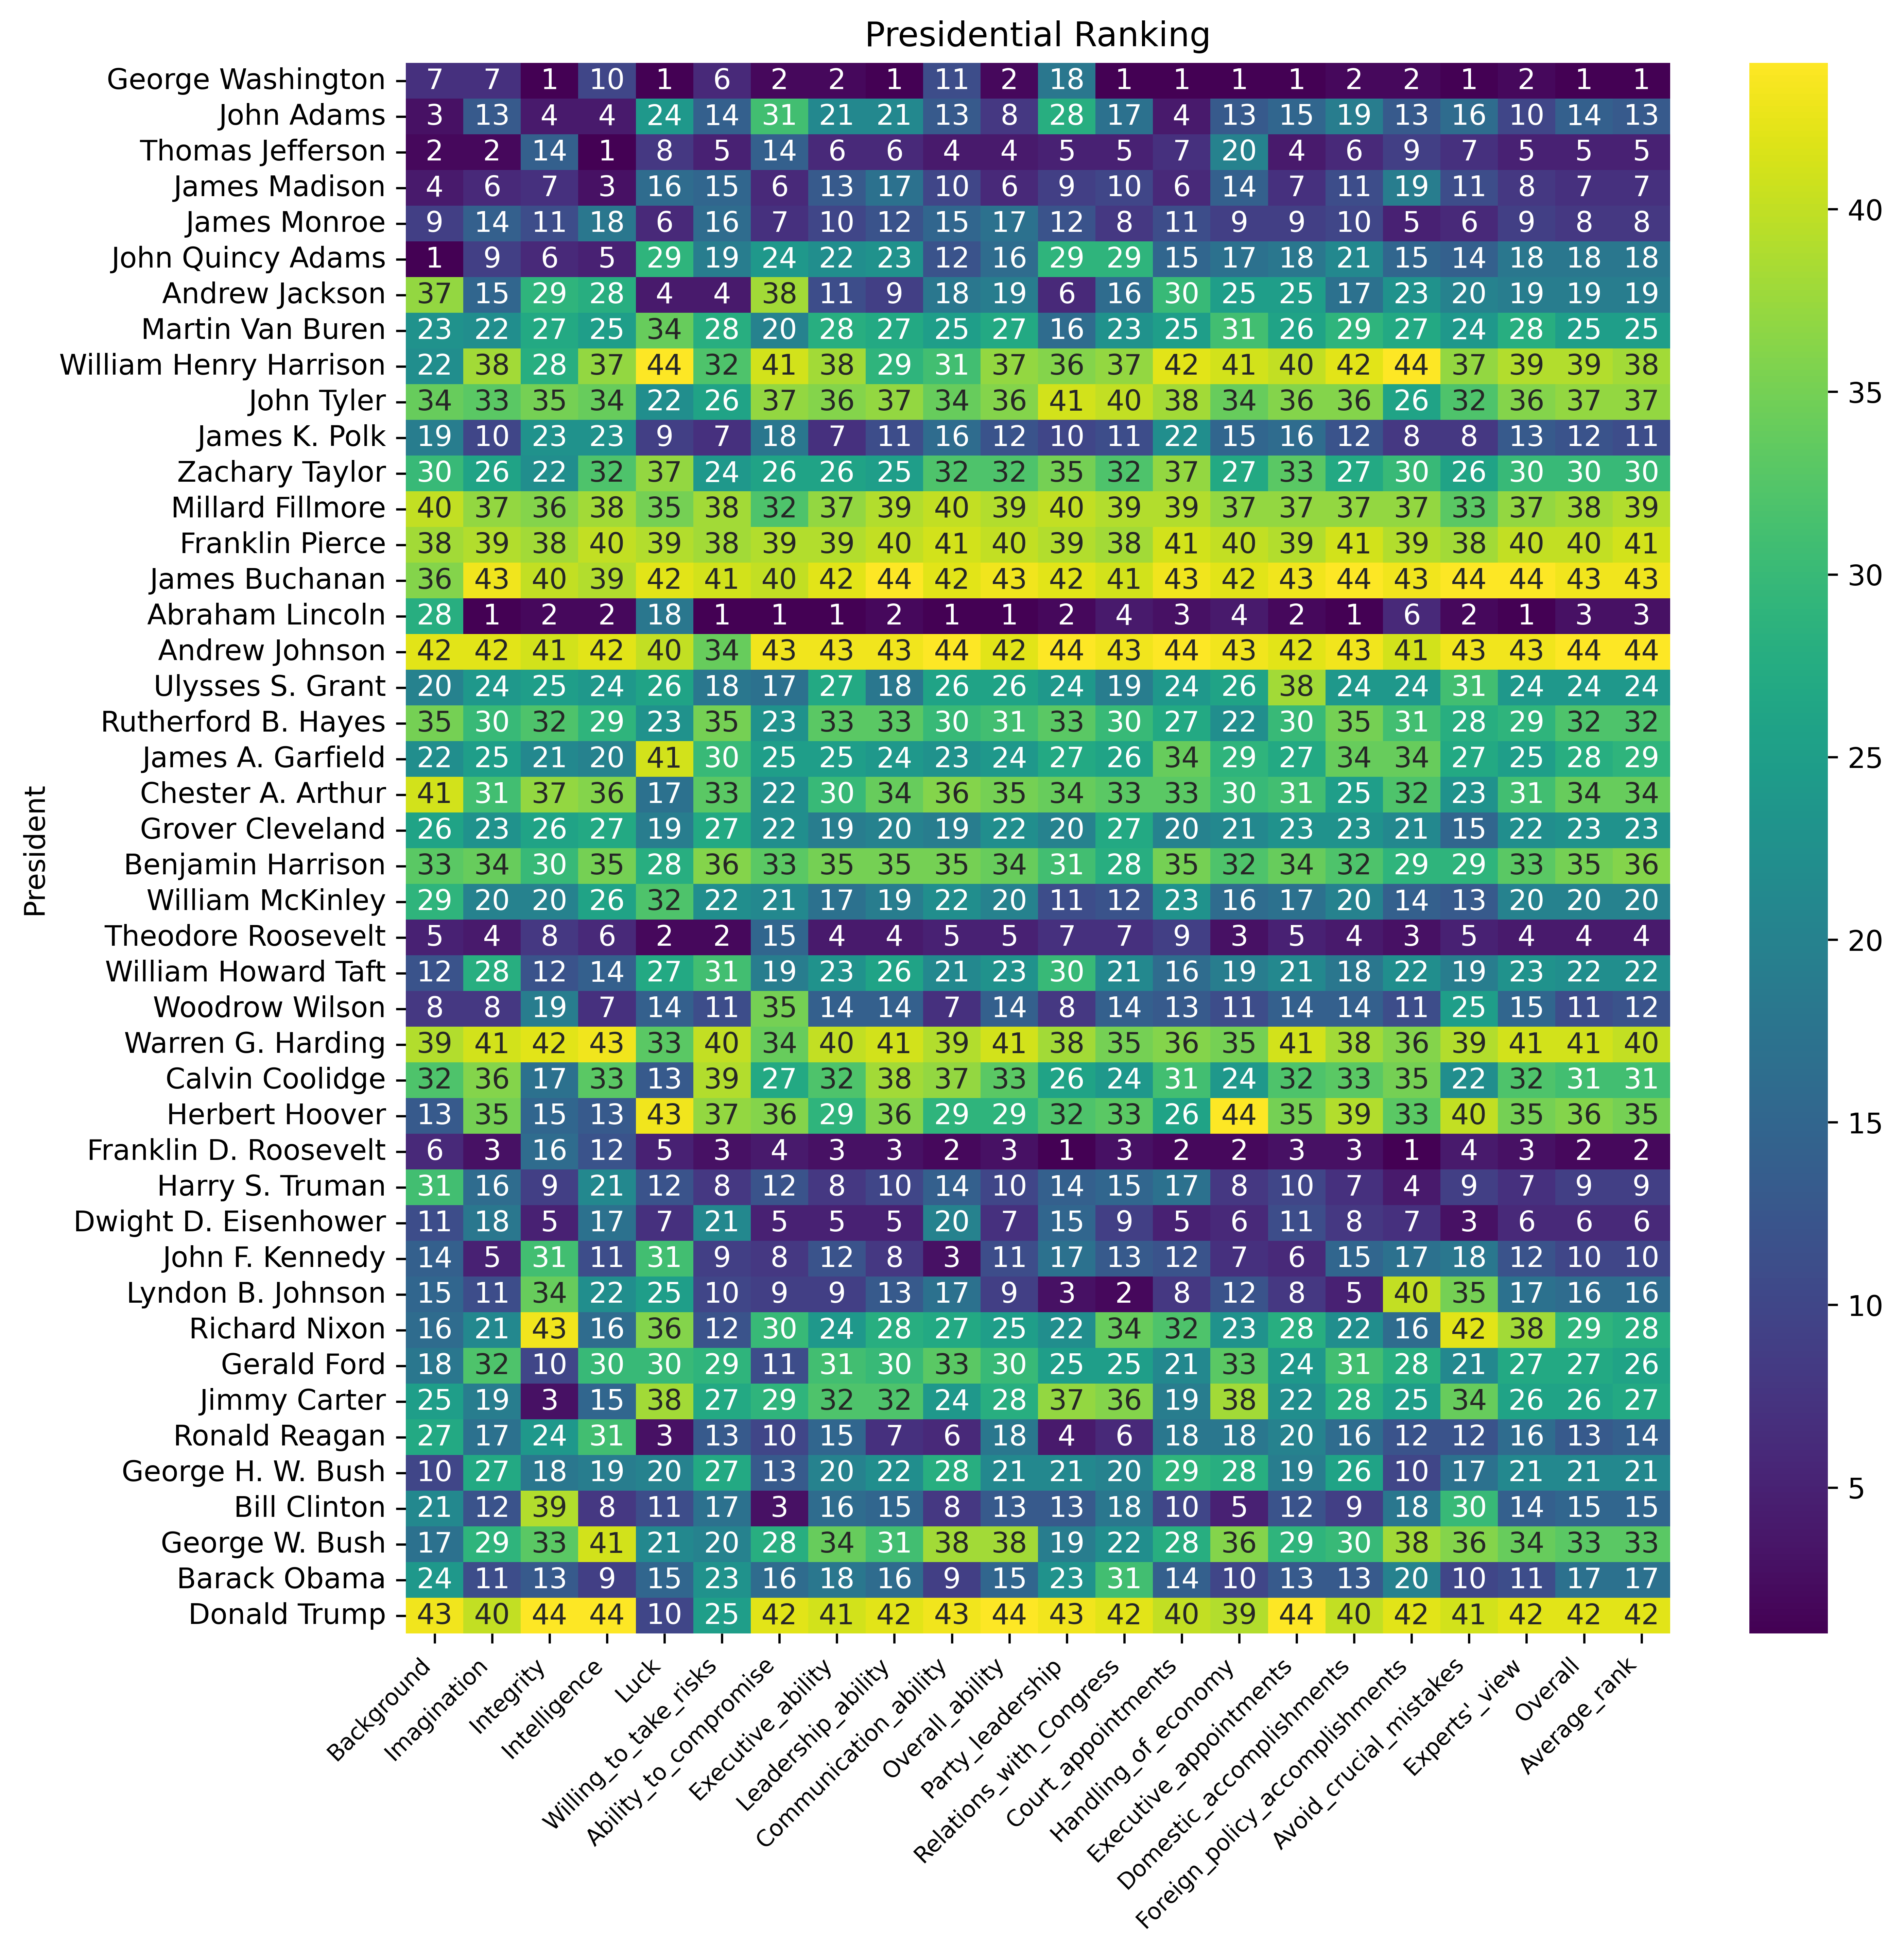

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize=(10,10), dpi=600)
g = sns.heatmap((tweak_siena_pres(df)     # doctest: +SKIP
   .set_index('President')
   .iloc[:,2:-1]
  ),annot=True, cmap='viridis', ax=ax)
g.set_xticklabels(g.get_xticklabels(), rotation=45, fontsize=8,
    ha='right')    # doctest: +SKIP
_ = plt.title('Presidential Ranking')
#fig.savefig('img/pandas2/20-pres.png', bbox_inches='tight')       # doctest: +SKIP

In [11]:
snow=pd.DataFrame(
    {'Obs Date': ['1980/01/01', '1980/01/02'],
    'Precip':['0.1', 'T'],
    'Snowfall': [1,0],
    'T.Obs':[25, 18]})

snow.rename(columns=lambda c: c.lower().replace(' ', '_').replace('.', '_'))\
    .assign(
        obs_date=lambda df2: pd.to_datetime(df2['obs_date']),
        precip=lambda df3: df3['precip'].str.replace("T", '0').astype('float')
    )

,obs_date,precip,snowfall,t_obs
0,1980-01-01,0.1,1,25
1,1980-01-02,0.0,0,18


```python 
 snow.columns = [c.lower().replace(' ', '_').replace('.', '_') for c in snow.columns]
```

# math operation

| Method | Description |
|---|---|
| .add(other, axis='columns', level=None, fill_value=None) | Add `other` to DataFrame across the axis. Unlike the operator, it can specify `fill_value`. |
| .sub(other, axis='columns', level=None, fill_value=None) | Subtract `other` from DataFrame across the axis. Unlike the operator, it can specify `fill_value`. |
| .mul(other, axis='columns', level=None, fill_value=None) | Multiply `other` with DataFrame across the axis. Unlike the operator, it can specify `fill_value`. |
| .div(other, axis='columns', level=None, fill_value=None) | Divide DataFrame by `other` across the axis. Unlike the operator, it can specify `fill_value`. |
| .truediv(other, axis='columns', level=None, fill_value=None) | Same as `.div`. |
| .floordiv(other, axis='columns', level=None, fill_value=None) | Integer-divide DataFrame by `other` across the axis. Unlike the operator, it can specify `fill_value`. |
| .mod(other, axis='columns', level=None, fill_value=None) | Perform modulo operation with `other` across the axis. Unlike the operator, it can specify `fill_value`. |
| .pow(other, axis='columns', level=None, fill_value=None) | Raise to `other` power across the axis. Unlike the operator, it can specify `fill_value`. |
| .dot(other) | Matrix multiply DataFrame by `other`. |
| .min(axis=None, skipna=None, numeric_only=None) | Return minimum value of each column. |
| .max(axis=None, skipna=None, numeric_only=None) | Return maximum value of each column. |
| .mean(axis=None, skipna=None, numeric_only=None) | Return mean value of each column. |
| np.cov(m, y=None, rowvar=True, bias=False, ddof=None, fweights=None, aweights=None) | Calculate covariance matrix. |


# loop and aggregation

## for loop
| Method | Description |
|---|---|
| .items() | Iterate over a tuple of column name and Series. |
| .itertuples(index=True, name="Pandas") | Iterate over namedtuples of rows. Includes index by default; `name` sets the namedtuple classname (or `None` for plain tuples). |

In [12]:
pres = tweak_siena_pres(df)
# iteration over columns (col_name, series) tuple
for col_name, col in pres.items():
    print(f'the column name is {col_name}, its type is {type(col)}, \
          and the non-NA count is {col.count()}')
    break

the column name is Seq, its type is <class 'pandas.Series'>,           and the non-NA count is 44


In [13]:
# iteration over rows as namedtuple (index as first item)
for tup in pres.itertuples():
    print(tup[0], tup.Seq) # this accesses the subtuple named "Seq"

1 1
2 2
3 3
4 4
5 5
6 6
7 7
8 8
9 9
10 10
11 11
12 12
13 13
14 14
15 15
16 16
17 17
18 18
19 19
20 20
21 21
22 22/24
23 23
24 25
25 26
26 27
27 28
28 29
29 30
30 31
31 32
32 33
33 34
34 35
35 36
36 37
37 38
38 39
39 40
40 41
41 42
42 43
43 44
44 45


## aggregation
create summary stats

| Method | Description |
|---|---|
| .sum(axis=0, skipna=True, level=None, numeric_only=None, min_count=0) | Return sum over the axis. Default of empty sequence is 0. Set `min_count=1` to return `NaN`. |
| .min(axis=0, skipna=True, level=None, numeric_only=None) | Return minimum over the axis. |
| .max(axis=0, skipna=True, level=None, numeric_only=None) | Return maximum over the axis. |
| .idxmin(axis=0, skipna=True) | Return the index of the first minimum value over the axis. |
| .idxmax(axis=0, skipna=True) | Return the index of the first maximum value over the axis. |
| .agg(func=None, axis=0, *args, **kwargs) | Aggregate using `func` over the axis. `func` can be a function, string, list/dict of functions/strings. |
| .describe(percentiles=[.25, .5, .75], include=None, exclude=None, datetime_is_numeric=False) | Return summary statistics for the DataFrame. |

In [14]:
scores = (pres.loc[:,'Background':'Average_rank']) # these are columns in numbers
scores.sum(axis=1) / len(scores.columns)

1      3.681818
2     14.454545
3      6.545455
4      9.636364
5     10.454545
6     17.181818
7     19.590909
8     25.681818
9     36.909091
10    34.409091
11    13.318182
12    29.500000
13    37.454545
14    39.409091
15    42.000000
16     4.045455
17    42.272727
18    24.227273
19    30.136364
20    27.272727
21    31.454545
22    22.181818
23    32.818182
24    19.727273
25     5.227273
26    21.318182
27    13.590909
28    38.772727
29    29.909091
30    31.954545
31     3.909091
32    11.818182
33     9.227273
34    12.727273
35    15.272727
36    26.909091
37    26.000000
38    26.818182
39    14.545455
40    20.818182
41    14.636364
42    30.363636
43    15.818182
44    39.772727
dtype: float64

In [15]:
scores.sum(axis='columns') / len(scores.columns) # sum value over these columns for each row

1      3.681818
2     14.454545
3      6.545455
4      9.636364
5     10.454545
6     17.181818
7     19.590909
8     25.681818
9     36.909091
10    34.409091
11    13.318182
12    29.500000
13    37.454545
14    39.409091
15    42.000000
16     4.045455
17    42.272727
18    24.227273
19    30.136364
20    27.272727
21    31.454545
22    22.181818
23    32.818182
24    19.727273
25     5.227273
26    21.318182
27    13.590909
28    38.772727
29    29.909091
30    31.954545
31     3.909091
32    11.818182
33     9.227273
34    12.727273
35    15.272727
36    26.909091
37    26.000000
38    26.818182
39    14.545455
40    20.818182
41    14.636364
42    30.363636
43    15.818182
44    39.772727
dtype: float64

In [16]:
df1=pd.Series([1,2.3,4,5])
display(df1.iloc[1])

def return_index1(df_series:pd.Series):
    return df_series.iloc[1]

print(return_index1(df1))

np.float64(2.3)

2.3


In [17]:
# aggregations with the .agg method.  we will count 
# the number of non-missing values for each column, the number of entries for 
# each column (including the missing values), the sum of each column, and run
# a custom aggregation (that returns the value for index 1):

display(pres.select_dtypes('number').agg(['count', 'sum','size', return_index1], axis=0))

,Background,Imagination,Integrity,Intelligence,Luck,Willing_to_take_risks,Ability_to_compromise,Executive_ability,Leadership_ability,Communication_ability,...,Relations_with_Congress,Court_appointments,Handling_of_economy,Executive_appointments,Domestic_accomplishments,Foreign_policy_accomplishments,Avoid_crucial_mistakes,Experts'_view,Overall,Average_rank
count,44,44,44,44,44,44,44,44,44,44,...,44,44,44,44,44,44,44,44,44,44
sum,968,957,990,990,990,953,968,978,990,990,...,979,990,990,990,990,990,990,990,990,990
size,44,44,44,44,44,44,44,44,44,44,...,44,44,44,44,44,44,44,44,44,44
return_index1,3,13,4,4,24,14,31,21,21,13,...,17,4,13,15,19,13,16,10,14,13


In [18]:
# alternative way to select the index using lambda function
pres['Background'].agg(lambda col: col.loc[1])

np.uint8(7)

In [19]:
# other ways to rename the aggregated series
display(pres.agg({'Luck': ['count', 'size'],'Overall': ['count', 'max']}))
display(pres.agg(Intelligence_count=('Intelligence', 'count'),Intelligence_size=('Intelligence', 'size')))

,Luck,Overall
count,44.0,44
size,44.0,NaN
max,NaN,44


,Intelligence
Intelligence_count,44
Intelligence_size,44


## apply method
| Method | Description |
|---|---|
| .apply(func=None, axis=0, raw=Fals
e, result_type=None, *args, **kwargs) | Apply `func` over the axis. If `func` returns a sequence, returns a DataFrame; if it returns a scalar, returns a Series. |

> Note: case_when use `np.select()` instead. `s.case_when(caselist)`. ( I don't use this!) Use `caselist` (list of tuples `(boolean_array, result)`) to simulate if-then statements.

> `.apply()` is slow. Below can be optimized using `.pipe()' because it directly works on a series.

```python 
pres
    .select_dtypes('number')
    .apply(lambda row: row.max()-row.min(), axis='columns')
    .rename('range') 
```

In [20]:
pres.select_dtypes('number')\
    .pipe(lambda df_:df_.max(axis='columns') - df_.min(axis='columns'))\
    .rename('range')

1     17
2     28
3     19
4     16
5     13
6     28
7     34
8     18
9     22
10    19
11    16
12    15
13     8
14     3
15     8
16    27
17    10
18    21
19    13
20    21
21    24
22    12
23     8
24    21
25    13
26    19
27    28
28    10
29    26
30    31
31    15
32    27
33    18
34    28
35    38
36    31
37    23
38    35
39    28
40    19
41    36
42    24
43    22
44    34
Name: range, dtype: uint8

# column type assign

| Method | Description |
|---|---|
| `astype(dtype, copy=True, errors='raise')` | Cast dataframe into `dtype`. (More common to use this on Series.) |
| `assign(**kwargs)` | Return a new DataFrame with updated or new columns. `kwargs` maps column name to function, scalar, or Series. If using a function, it is passed the current state of the DataFrame and should return a scalar or Series. Subsequent columns may reference earlier columns in `kwargs` if you use a function. |
| `memory_usage(index=True, deep=False)` | Return a Series with the memory usage of each column in bytes. By default includes index. Use `deep=True` to show how much space object columns consume. |
| `info(verbose=None, buf=None, max_cols=None, memory_usage=None, show_counts=None)` | Print summary of DataFrame to stdout. Use `memory_usage='deep'` to show object column memory usage. |

> `.astype({'<column name>': '<data type>'})`

In [21]:
import io
billing_data = \
'''cancel_date,period_start,start_date,end_date,rev,sum_payments
12/1/2019,1/1/2020,12/15/2019,5/15/2020,999,50
,1/1/2020,12/15/2019,5/15/2020,999,50
,1/1/2020,12/15/2019,5/15/2020,999,1950
1/20/2020,1/1/2020,12/15/2019,5/15/2020,499,0
,1/1/2020,12/24/2019,5/24/2020,699,100
,1/1/2020,11/29/2019,4/29/2020,799,250
,1/1/2020,1/15/2020,4/29/2020,799,250'''

bill_df = pd.read_csv(io.StringIO(billing_data),
    parse_dates=['cancel_date', 'period_start', 'start_date',
                 'end_date'])
bill_df

,cancel_date,period_start,start_date,end_date,rev,sum_payments
0,2019-12-01,2020-01-01,2019-12-15,2020-05-15,999,50
1,NaT,2020-01-01,2019-12-15,2020-05-15,999,50
2,NaT,2020-01-01,2019-12-15,2020-05-15,999,1950
3,2020-01-20,2020-01-01,2019-12-15,2020-05-15,499,0
4,NaT,2020-01-01,2019-12-24,2020-05-24,699,100
5,NaT,2020-01-01,2019-11-29,2020-04-29,799,250
6,NaT,2020-01-01,2020-01-15,2020-04-29,799,250


In [22]:
cols=bill_df.select_dtypes('int64').columns
print(cols)

Index(['rev', 'sum_payments'], dtype='str')


In [23]:
bill_df.astype({col: 'uint8' for col in cols}) # reduce memory usage when values are small non-negative integers.

,cancel_date,period_start,start_date,end_date,rev,sum_payments
0,2019-12-01,2020-01-01,2019-12-15,2020-05-15,231,50
1,NaT,2020-01-01,2019-12-15,2020-05-15,231,50
2,NaT,2020-01-01,2019-12-15,2020-05-15,231,158
3,2020-01-20,2020-01-01,2019-12-15,2020-05-15,243,0
4,NaT,2020-01-01,2019-12-24,2020-05-24,187,100
5,NaT,2020-01-01,2019-11-29,2020-04-29,31,250
6,NaT,2020-01-01,2020-01-15,2020-04-29,31,250


### practice

In [24]:
# creates a new column called Average_rank by doing this: 
# Take all columns stored as uint8.
# Add those values across each row to get one total score per row.
# Rank the rows by that total score.
# Use dense ranking (same value, same rank, not skip), so ties share the same rank and the next rank number is not skipped.
# Save that rank as uint8 in the new Average_rank column.

bill_df.assign(Average_rank=(lambda df_:df_[cols].agg('sum', axis=1).rank(method='dense').astype('uint8') ))

,cancel_date,period_start,start_date,end_date,rev,sum_payments,Average_rank
0,2019-12-01,2020-01-01,2019-12-15,2020-05-15,999,50,3
1,NaT,2020-01-01,2019-12-15,2020-05-15,999,50,3
2,NaT,2020-01-01,2019-12-15,2020-05-15,999,1950,4
3,2020-01-20,2020-01-01,2019-12-15,2020-05-15,499,0,1
4,NaT,2020-01-01,2019-12-24,2020-05-24,699,100,2
5,NaT,2020-01-01,2019-11-29,2020-04-29,799,250,3
6,NaT,2020-01-01,2020-01-15,2020-04-29,799,250,3


In [25]:
bill_df[cols].agg('sum', axis=1).rank(method='dense').astype('uint8')

0    3
1    3
2    4
3    1
4    2
5    3
6    3
dtype: uint8

>> the lambda function in the assign uses the series as the input and return a series. But it also works by returning a scalar and broadcast to a new column. 

In [26]:
# lowest rank
bill_df.assign(Median_rank=\
               (lambda df_:df_[cols].agg('sum', axis=1)\
       .rank(method='dense').quantile(0.5).astype('uint8') ))

,cancel_date,period_start,start_date,end_date,rev,sum_payments,Median_rank
0,2019-12-01,2020-01-01,2019-12-15,2020-05-15,999,50,3
1,NaT,2020-01-01,2019-12-15,2020-05-15,999,50,3
2,NaT,2020-01-01,2019-12-15,2020-05-15,999,1950,3
3,2020-01-20,2020-01-01,2019-12-15,2020-05-15,499,0,3
4,NaT,2020-01-01,2019-12-24,2020-05-24,699,100,3
5,NaT,2020-01-01,2019-11-29,2020-04-29,799,250,3
6,NaT,2020-01-01,2020-01-15,2020-04-29,799,250,3


# create and update columns

| Method | Description |
|---|---|
| `rename(mapper=None, index=None, columns=None, axis=0, copy=True, level=None, errors='ignore')` | Change axis labels. Pass `columns` or `index` as a dictionary (mapping old values to new values) or a function (accepting the old value and returning the new value). |
| `replace(to_replace=None, value=None, limit=None, regex=False, method='pad')` | Replace values from `to_replace` (string, regex, number, Series, list, or dict mapping replacements) with `value`. If `to_replace` is a list and `value` is `None`, you can fill using `method='bfill'` or `'ffill'`. |
| `drop(labels=None, axis=0, index=None, columns=None, level=None, errors='raise')` | Drop rows or columns with specified labels. Prefer `columns='age'` rather than `labels='age'` with `axis=1`. |
| `dropna(axis=0, how='any', thresh=None, subset=None)` | Drop rows (`axis=0`) or columns (`axis=1`) with missing values. Use `thresh` to require a minimum number of non-NA values. Limit operation to specific columns with `subset`. |
| `query(expr)` | Evaluate `expr` to filter the DataFrame. Refer to Python variables by prefixing with `@`. Use backticks around column names that contain spaces or special characters. |
| `assign(**kwargs)` | Return a new DataFrame with updated or new columns. `kwargs` maps column name to a function, scalar, or Series. If using a function, it is passed the current state of the DataFrame and should return a scalar or Series. Subsequent columns may reference earlier `kwargs` columns when functions are used. |

In [27]:
import pandas as pd
import numpy as np
from IPython.display import display

url = 'https://github.com/mattharrison/datasets/raw/master/data/'\
      '2020-jetbrains-python-survey.csv'
jb = pd.read_csv(url)
jb.head(3)

C:\Users\xiang\AppData\Local\Temp\ipykernel_14840\768372622.py:7: DtypeWarning: Columns (0: develop.for.cloud.Other) have mixed types. Specify dtype option on import or set low_memory=False.
  jb = pd.read_csv(url)


,is.python.main,other.lang.None,other.lang.Java,other.lang.JavaScript,other.lang.C/C++,other.lang.PHP,other.lang.C#,other.lang.Ruby,other.lang.Bash / Shell,other.lang.Objective-C,...,job.role.Technical support,job.role.Data analyst,job.role.Business analyst,job.role.Team lead,job.role.Product manager,job.role.CIO / CEO / CTO,job.role.Systems analyst,job.role.Other,age,country.live
0,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bash / Shell,NaN,...,NaN,NaN,Business analyst,NaN,NaN,NaN,NaN,NaN,30–39,NaN
1,Yes,NaN,Java,JavaScript,NaN,NaN,C#,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21–29,India
2,Yes,NaN,NaN,NaN,C/C++,NaN,NaN,NaN,Bash / Shell,NaN,...,Technical support,Data analyst,NaN,Team lead,NaN,NaN,NaN,NaN,30–39,United States


### practice 1
Exercise: "bigdata.apache 1" and "bigdata.apache 2" should share the same key. 
- Import the collections module.
- Create a dictionary-like container where each key starts with an empty list by default.
    - Loop through the column names of jb, in sorted order.
    - For each column name:
        - Count how many . characters it has.
        - If it has 2 or more dots, keep the first 2 parts after splitting by ..
        - Otherwise, keep only the first part.
    - Join the kept parts back using . to form a group key.
- Add the original column name into the list for that group key.

In [28]:
from collections import defaultdict
d=defaultdict(list)
sorted_colname=jb.columns.sort_values()
for colname in sorted_colname:
    if colname.count('.')>=2:
        name1=colname.split('.')[0:2]
        part1=str(name1[0])+'.'+str(name1[1])
    else:
        part1=str(colname.split('.')[0] )
    d[part1].append(colname)

print(d)

defaultdict(<class 'list'>, {'age': ['age'], 'are.you': ['are.you.datascientist'], 'bigdata': ['bigdata.Apache Beam', 'bigdata.Apache Flink', 'bigdata.Apache Hadoop/MapReduce', 'bigdata.Apache Hive', 'bigdata.Apache Kafka', 'bigdata.Apache Samza', 'bigdata.Apache Spark', 'bigdata.Apache Tez', 'bigdata.ClickHouse', 'bigdata.Dask', 'bigdata.None', 'bigdata.Other'], 'ci': ['ci.AppVeyor', 'ci.Bamboo', 'ci.CircleCI', 'ci.CruiseControl', 'ci.Gitlab CI', 'ci.Jenkins / Hudson', 'ci.None', 'ci.Other', 'ci.TeamCity', 'ci.Travis CI'], 'cloud.platform': ['cloud.platform.AWS', 'cloud.platform.DigitalOcean', 'cloud.platform.Google Cloud Platform', 'cloud.platform.Heroku', 'cloud.platform.Linode', 'cloud.platform.Microsoft Azure', 'cloud.platform.None', 'cloud.platform.OpenShift', 'cloud.platform.OpenStack', 'cloud.platform.Other', 'cloud.platform.PythonAnywhere', 'cloud.platform.Rackspace'], 'company': ['company.size'], 'configuration.management': ['configuration.management.Ansible', 'configuration.

In [29]:
uniq_cols = []
for cols in d.values():
    if len(cols) == 1:
        uniq_cols.extend(cols)
display(uniq_cols)

['age',
 'are.you.datascientist',
 'company.size',
 'country.live',
 'employment.status',
 'first.learn.about.main.ide',
 'how.often.use.main.ide',
 'ide.main',
 'is.python.main',
 'job.team',
 'main.purposes',
 'missing.features.main.ide',
 'nps.main.ide',
 'python.years',
 'python2.version.most',
 'python3.version.most',
 'several.projects',
 'team.size',
 'use.python.most',
 'years.of.coding']

In [30]:
# ch
jb[uniq_cols].rename(columns=lambda c: c.replace('.', '_'))['age'].value_counts(dropna=False)

age
NaN            29701
21–29           9710
30–39           7512
40–49           3010
18–20           2567
50–59           1374
60 or older      588
Name: count, dtype: int64

In [31]:
jb[uniq_cols].rename(columns=lambda c: c.replace('.', '_'))['age'].where(jb['age'].isna(),jb['age'].str.slice(0,2)).astype('float')

0        30.0
1        21.0
2        30.0
3         NaN
4        21.0
         ... 
54457    21.0
54458     NaN
54459    21.0
54460    30.0
54461    21.0
Name: age, Length: 54462, dtype: float64

> Note: the work flow of cleaning NaN is different in `parrow` type

In [32]:
# this is not recommended
jb2 = jb[uniq_cols]
age_slice = jb.age.str.slice(0, 2)
age_float = age_slice.astype(float)
age_int = age_float.astype('Int64')
jb2['age'] = age_int

In [33]:
# use assign to update an existing column
jb[uniq_cols]\
    .rename(columns=lambda c: c.replace('.', '_'))\
    .assign(age=lambda df_:df_['age'].str.slice(0,2).replace('', np.nan).astype('float')).tail(3)


,age,are_you_datascientist,company_size,country_live,employment_status,first_learn_about_main_ide,how_often_use_main_ide,ide_main,is_python_main,job_team,main_purposes,missing_features_main_ide,nps_main_ide,python_years,python2_version_most,python3_version_most,several_projects,team_size,use_python_most,years_of_coding
54459,21.0,NaN,Just me,Russian Federation,Self-employed (a person earning income directl...,Friend / Colleague,Daily,PyCharm Professional Edition,Yes,Work in a team,Both for work and personal,"No, it has all the features I need",10.0,3–5 years,NaN,Python 3_7,"Yes, I work on many different projects",2-7 people,Web development,6–10 years
54460,30.0,Yes,51–500,Spain,Fully employed by a company / organization,Search engines,Daily,Other,Yes,Work on your own project(s) independently,Both for work and personal,Yes – Please list:,3.0,6–10 years,NaN,Python 3_7,"Yes, I work on many different projects",NaN,Data analysis,3–5 years
54461,21.0,NaN,11–50,Algeria,Fully employed by a company / organization,Online learning platform / Online course,Daily,VS Code,Yes,Work in a team,Both for work and personal,"No, it has all the features I need",10.0,1–2 years,NaN,Python 3_8,"Yes, I work on many different projects",2-7 people,NaN,1–2 years


In [34]:
(jb
 [uniq_cols]
 .rename(columns=lambda c: c.replace('.', '_'))
 .assign(age=lambda df_:df_.age.str.slice(0,2)
                           .astype(float).astype('Int64'),
         are_you_datascientist=lambda df_: df_.are_you_datascientist
            .replace({'Yes': True, 'No': False, np.nan: False}).astype('bool')
        )
 .are_you_datascientist
)

0        False
1         True
2        False
3        False
4        False
         ...  
54457    False
54458    False
54459    False
54460     True
54461    False
Name: are_you_datascientist, Length: 54462, dtype: bool

>> Note: see code below for the reason why using T or F instead of 1 or 0

In [35]:
display(pd.Series(['1','0']).astype('bool'))
display(pd.Series(['1','0']).astype('int8').astype('bool'))

0    True
1    True
dtype: bool

0     True
1    False
dtype: bool

### practice 2

`team_size`
- Split on en-dash, pull out the first column
- replace 'More than 40' with 41
- replace values where company_size is 1 with 1
- convert it to a float.

In [36]:
jb[uniq_cols].rename(columns=lambda c: c.replace('.', '_'))['team_size'].value_counts()

team_size
2-7 people             8899
8-12 people            1947
13-20 people            640
21-40 people            258
More than 40 people     225
Name: count, dtype: int64

In [37]:
display(jb[uniq_cols].rename(columns=lambda c: c.replace('.', '_'))['team_size']\
.astype('string')\
.str.split('-', n=1, expand=True).head(5))

# <NA> means the value is missing aka it is ''.

,0,1
0,<NA>,<NA>
1,2,7 people
2,<NA>,<NA>
3,<NA>,<NA>
4,<NA>,<NA>


In [38]:
# since the missing value is pd.NA
jb[uniq_cols].rename(columns=lambda c: c.replace('.', '_'))['team_size']\
.astype('string')\
.str.split('-', n=1, expand=True).iloc[:,0]\
.apply(lambda x: pd.NA if x is pd.NA else x)

0        NaN
1          2
2        NaN
3        NaN
4        NaN
        ... 
54457    NaN
54458    NaN
54459      2
54460    NaN
54461      2
Name: 0, Length: 54462, dtype: str

In [39]:
# the book's approach is using string replace based on ''
jb[uniq_cols].rename(columns=lambda c: c.replace('.', '_'))['team_size']\
.astype('string')\
.str.split('-', n=1, expand=True).iloc[:,0]\
.replace('', pd.NA)

0        <NA>
1           2
2        <NA>
3        <NA>
4        <NA>
         ... 
54457    <NA>
54458    <NA>
54459       2
54460    <NA>
54461       2
Name: 0, Length: 54462, dtype: string

### practice 3

In [40]:
jb[uniq_cols].rename(columns=lambda c: c.replace('.', '_'))['years_of_coding']

0               1–2 years
1               3–5 years
2               3–5 years
3               11+ years
4        Less than 1 year
               ...       
54457           1–2 years
54458           1–2 years
54459          6–10 years
54460           3–5 years
54461           1–2 years
Name: years_of_coding, Length: 54462, dtype: str

In [41]:
jb[uniq_cols].rename(columns=lambda c: c.replace('.', '_'))['company_size'].value_counts()

company_size
51–500             4608
More than 5,000    3635
11–50              3507
2–10               2558
1,001–5,000        1934
Just me            1492
501–1,000          1165
Not sure            526
Name: count, dtype: int64

In [42]:
# country_live - Convert to categorical.
# employment_status - Fill missing values with 'Other' and convert to categorical.
# is_python_main - Convert to categorical.
# team_size - Split on en-dash, pull out the first column, replace 'More than
# 40' with 41, replace values where company_size is 1 with 1, and convert it to a float.
# years_of_coding - Replace 'Less than 1 year' with .5, then pull out any
# numbers with a regular expression and convert them to floats.
# python_years - Replace '_' with '.', then pull out any numbers with a
# regular expression and convert them to floats.
# use_python_most - Replace missing values with 'Unknown'.

company_size_dict={'Just me': '1', '': pd.NA,
     'Not sure': np.nan, 'More than 5,000': '5000',
     '2–10': '2', '11–50':'11','51–500': '51', '501–1,000':'501',
     '1,001–5,000':'1001'}

jb[uniq_cols]\
.rename(columns=lambda c: c.replace('.', '_'))\
.assign(company_size=lambda df_:df_.company_size.replace(company_size_dict).astype('float'),
     country_live=lambda df_: df_.country_live.astype('category'),
     employment_status=lambda df_: df_.employment_status.fillna('Other').astype('category'),
     is_python_main=lambda df_: df_.is_python_main.astype('category'),
     team_size=lambda df_: df_.team_size\
          .str.split('-', n=1, expand=True)\
          .iloc[:,0]\
          .replace('More than 40 people', '41')\
          .where(df_.company_size!=1, '1')\
          .replace('', pd.NA),
     years_of_coding=lambda df_:df_.years_of_coding.replace('Less than 1 year', '.5')\
          .str.extract(r'(?P<years_of_coding>\.?\d+)')\
          .astype('float64'),
     python_years=lambda df_:df_.python_years.replace('Less than 1 year', '.5')\
          .str.extract(r'(?P<python_years>\.?\d+)')\
          .astype('float64'),
     python3_ver=lambda df_:df_.python3_version_most.str.replace('_', '.')\
          .str.extract(r'(?P<python3_ver>\d\.\d)'),
     use_python_most=lambda df_:df_.use_python_most.fillna('Unknown')
     )\
.drop(columns=['python2_version_most'])\
.head(5)

,age,are_you_datascientist,company_size,country_live,employment_status,first_learn_about_main_ide,how_often_use_main_ide,ide_main,is_python_main,job_team,main_purposes,missing_features_main_ide,nps_main_ide,python_years,python3_version_most,several_projects,team_size,use_python_most,years_of_coding,python3_ver
0,30–39,NaN,1.0,NaN,Partially employed by a company / organization,Conference / User Group,Weekly,PyCharm Community Edition,Yes,Work as an external consultant or trainer,For work,"No, it has all the features I need",3.0,3.0,Python 3_7,"Yes, I work on many different projects",1,Unknown,1.0,3.7
1,21–29,Yes,5000.0,India,Fully employed by a company / organization,School / University,Daily,VS Code,Yes,Work in a team,Both for work and personal,"No, it has all the features I need",8.0,3.0,Python 3_6,"Yes, I work on one main and several side projects",2,Software prototyping,3.0,3.6
2,30–39,No,5000.0,United States,Fully employed by a company / organization,Friend / Colleague,Daily,Vim,Yes,Work on your own project(s) independently,Both for work and personal,"No, it has all the features I need",10.0,3.0,Python 3_6,"Yes, I work on one main and several side projects",NaN,DevOps / System administration / Writing autom...,3.0,3.6
3,NaN,NaN,NaN,NaN,Other,Friend / Colleague,Daily,PyCharm Professional Edition,Yes,NaN,Both for work and personal,Yes – Please list:,10.0,11.0,Python 3_8,"Yes, I work on many different projects",NaN,Web development,11.0,3.8
4,21–29,NaN,NaN,Italy,Student,Search engines,Daily,VS Code,Yes,Work on your own project(s) independently,"For personal, educational or side projects","No, it has all the features I need",10.0,1.0,Python 3_8,"Yes, I work on one main and several side projects",NaN,Web development,0.5,3.8


In [43]:
# practice using pipe for the entire dataframe
jb[uniq_cols]\
.rename(columns=lambda c: c.replace('.', '_'))\
.pipe(lambda df_: df_.assign(\
    age=df_.age.str.slice(0,2).astype('int8[pyarrow]'),\
    are_you_datascientist=df_.are_you_datascientist\
        .replace({'Yes': '1', 'No': '0', '': '0', 'Other': '0'})\
        .astype('bool'),\
    country_live=df_.country_live.astype('category'),\
    employment_status=df_.employment_status.fillna('Other').astype('category'))).head(5)

,age,are_you_datascientist,company_size,country_live,employment_status,first_learn_about_main_ide,how_often_use_main_ide,ide_main,is_python_main,job_team,main_purposes,missing_features_main_ide,nps_main_ide,python_years,python2_version_most,python3_version_most,several_projects,team_size,use_python_most,years_of_coding
0,30,True,Just me,NaN,Partially employed by a company / organization,Conference / User Group,Weekly,PyCharm Community Edition,Yes,Work as an external consultant or trainer,For work,"No, it has all the features I need",3.0,3–5 years,NaN,Python 3_7,"Yes, I work on many different projects",NaN,NaN,1–2 years
1,21,True,"More than 5,000",India,Fully employed by a company / organization,School / University,Daily,VS Code,Yes,Work in a team,Both for work and personal,"No, it has all the features I need",8.0,3–5 years,NaN,Python 3_6,"Yes, I work on one main and several side projects",2-7 people,Software prototyping,3–5 years
2,30,True,"More than 5,000",United States,Fully employed by a company / organization,Friend / Colleague,Daily,Vim,Yes,Work on your own project(s) independently,Both for work and personal,"No, it has all the features I need",10.0,3–5 years,NaN,Python 3_6,"Yes, I work on one main and several side projects",NaN,DevOps / System administration / Writing autom...,3–5 years
3,<NA>,True,NaN,NaN,Other,Friend / Colleague,Daily,PyCharm Professional Edition,Yes,NaN,Both for work and personal,Yes – Please list:,10.0,11+ years,NaN,Python 3_8,"Yes, I work on many different projects",NaN,Web development,11+ years
4,21,True,NaN,Italy,Student,Search engines,Daily,VS Code,Yes,Work on your own project(s) independently,"For personal, educational or side projects","No, it has all the features I need",10.0,1–2 years,NaN,Python 3_8,"Yes, I work on one main and several side projects",NaN,Web development,Less than 1 year


# Missing and Duplicated Data

Many machine learning models will fail if you try to train them on dataframes with missing values. Once missing values are found, I can drop missing values with `.dropna`. There is a `.fillna`and an `.interpolate` method on the dataframe.

A sample work flow to treat missing data is
- check if missing values are present
    - check the proportion of missing values
        - impute data
        - or delete rows with missing values

| Method | Description |
|---|---|
| `.isna()` | Return a boolean DataFrame with the same dimensions with `True` where cells are missing. |
| `.sum(axis=0, skipna=True, level=None, numeric_only=None, min_count=0)` | Return sum over the axis. The default for an empty sequence is `0`; set `min_count=1` to require at least one non-NA value (otherwise returns `NaN`). |
| `.mean(axis=0, skipna=True, level=None, numeric_only=None)` | Return mean over the axis (ignores NA by default when `skipna=True`). |
| `.drop_duplicates(subset=None, keep='first', ignore_index=False)` | Return a DataFrame with duplicated rows removed. Use `subset` to consider specific columns. `keep` may be `'first'`, `'last'`, or `False` (drop all duplicates). Set `ignore_index=True` to reset the index. |

In [44]:
pres.isna().sum()

Seq                               0
President                         0
Party                             0
Background                        0
Imagination                       0
Integrity                         0
Intelligence                      0
Luck                              0
Willing_to_take_risks             0
Ability_to_compromise             0
Executive_ability                 0
Leadership_ability                0
Communication_ability             0
Overall_ability                   0
Party_leadership                  0
Relations_with_Congress           0
Court_appointments                0
Handling_of_economy               0
Executive_appointments            0
Domestic_accomplishments          0
Foreign_policy_accomplishments    0
Avoid_crucial_mistakes            0
Experts'_view                     0
Overall                           0
Average_rank                      0
Quartile                          0
dtype: int64

In [45]:
# pres[pres.Integrity.isna()]
pres.query('Integrity.isna()')

,Seq,President,Party,Background,Imagination,Integrity,Intelligence,Luck,Willing_to_take_risks,Ability_to_compromise,...,Court_appointments,Handling_of_economy,Executive_appointments,Domestic_accomplishments,Foreign_policy_accomplishments,Avoid_crucial_mistakes,Experts'_view,Overall,Average_rank,Quartile


# Sorting Columns and Indexes

## sort columns
| Method | Description |
|---|---|
| `.sort_values(by, axis=0, ascending=True, kind='quicksort', na_position='last', ignore_index=False, key=None)` | Return dataframe with values sorted along the axis. Use `by` to specify a column (string) or a list of columns (for `axis=0`). You can use `kind='mergesort'` or `kind='stable'` for a stable sort if only sorting one column. A `key` function accepts a `Series` and should return a `Series` with the same index. |

In [46]:
display(pres.sort_values(by=['Party', 'Average_rank'],ascending=[True, False]).head(3))

,Seq,President,Party,Background,Imagination,Integrity,Intelligence,Luck,Willing_to_take_risks,Ability_to_compromise,...,Court_appointments,Handling_of_economy,Executive_appointments,Domestic_accomplishments,Foreign_policy_accomplishments,Avoid_crucial_mistakes,Experts'_view,Overall,Average_rank,Quartile
17,17,Andrew Johnson,Democratic,42,42,41,42,40,34,43,...,44,43,42,43,41,43,43,44,44,4th
15,15,James Buchanan,Democratic,36,43,40,39,42,41,40,...,43,42,43,44,43,44,44,43,43,4th
14,14,Franklin Pierce,Democratic,38,39,38,40,39,38,39,...,41,40,39,41,39,38,40,40,41,4th


### practice 1

sort the last name of the president

In [47]:
# way 1 of extracting the last name
pres['President'].str.split(' ').str[-1].head(4)

1    Washington
2         Adams
3     Jefferson
4       Madison
Name: President, dtype: object

In [48]:
# way 2 of extracting the last name
pres['President'].str.split(' ').apply(lambda val: val[-1]).head(4)

1    Washington
2         Adams
3     Jefferson
4       Madison
Name: President, dtype: str

In [49]:
# putting above into the key function for the sort
pres.sort_values(by='President',\
    key=lambda name_ser: name_ser.astype(str).str.split().str[-1])\
.President.head(4)

2            John Adams
6     John Quincy Adams
21    Chester A. Arthur
15       James Buchanan
Name: President, dtype: str

## Sorting Column Order
| Method | Description |
|---|---|
| `.sort_index(axis=0, level=None, ascending=True, kind='quicksort', na_position='last', sort_remaining=True, ignore_index=False, key=None)` | Return dataframe with index (`axis=0`) or columns (`axis=1`) sorted. Can specify a single level or multiple levels with `level`. Can specify the column (string) or a list of columns (for `axis=0`). Can use `kind='mergesort'` or `kind='stable'` for a stable sort if only sorting one column. You can reset the index with `ignore_index`. A `key` function accepts an index and should return an index. For multi-level indexes, each index is passed in independently to the function. |

In [50]:
pres.sort_index(axis='columns').head(3)

,Ability_to_compromise,Average_rank,Avoid_crucial_mistakes,Background,Communication_ability,Court_appointments,Domestic_accomplishments,Executive_ability,Executive_appointments,Experts'_view,...,Luck,Overall,Overall_ability,Party,Party_leadership,President,Quartile,Relations_with_Congress,Seq,Willing_to_take_risks
1,2,1,1,7,11,1,2,2,1,2,...,1,1,2,Independent,18,George Washington,1st,1,1,6
2,31,13,16,3,13,4,19,21,15,10,...,24,14,8,Federalist,28,John Adams,2nd,17,2,14
3,14,5,7,2,4,7,6,6,4,5,...,8,5,4,Democratic-Republican,5,Thomas Jefferson,1st,5,3,5


## Setting and Sorting the Index
Sorting the index allows us to slice the index by name.
| Method | Description |
|---|---|
| `.set_index(keys, drop=True, append=False, verify_integrity=False)` | Return dataframe with the new index. The `keys` argument can be a column name, a `Series` (or numpy array) of labels for the index, or a list of column names or series. The `drop` parameter indicates whether to remove columns used for the index. The `append` parameter allows you to add additional index levels. You can check for duplicate index values by setting `verify_integrity=True`. |
| `.loc` | Attribute to index off of by index and column names. Slices use the closed interval (including start and end). |


In [51]:
pres.set_index('Party').sort_index().loc['Democratic':'Republican'].tail(3)

,Seq,President,Background,Imagination,Integrity,Intelligence,Luck,Willing_to_take_risks,Ability_to_compromise,Executive_ability,...,Court_appointments,Handling_of_economy,Executive_appointments,Domestic_accomplishments,Foreign_policy_accomplishments,Avoid_crucial_mistakes,Experts'_view,Overall,Average_rank,Quartile
Party,,,,,,,,,,,,,,,,,,,,,
Republican,23,Benjamin Harrison,33,34,30,35,28,36,33,35,...,35,32,34,32,29,29,33,35,36,4th
Republican,18,Ulysses S. Grant,20,24,25,24,26,18,17,27,...,24,26,38,24,24,31,24,24,24,3rd
Republican,45,Donald Trump,43,40,44,44,10,25,42,41,...,40,39,44,40,42,41,42,42,42,4th


In [52]:
pres.set_index('Party').sort_index().loc['Democratic':'Republican', ['President']].tail(3)
# note: ['President'] returns a data frame; 'President' returns a Pandas Series.

,President
Party,
Republican,Benjamin Harrison
Republican,Ulysses S. Grant
Republican,Donald Trump


# Filtering and Indexing Operations

## rename index
| Method | Description |
|---|---|
| `.rename(mapper=None, index=None, columns=None, axis=0, copy=True, level=None, errors='ignore')` | Change axis labels. Pass the `columns` or `index` as a dictionary (mapping old values to new values) or a function (accepting the old value and returning the new value). |

In [53]:
str0='George Washington'
print([f'here', str0.split()[1:]])
# * is the Python "unpacking" / "star" operator. 
# It expands (or collects) elements from an iterable
print([f'here', *str0.split()[1:]]) 

# 1) Unpacking a mapping into keyword arguments
def greet(name, age):
    print(f"{name} is {age} years old.")

person = {"name": "Alice", "age": 30}
greet(**person)   # same as greet(name="Alice", age=30)

# 2) Merging dictionaries
base = {"host": "localhost", "port": 5432}
override = {"port": 5433, "debug": True}

config = {**base, **override}
print(config)     # {'host': 'localhost', 'port': 5433, 'debug': True}



['here', ['Washington']]
['here', 'Washington']
Alice is 30 years old.
{'host': 'localhost', 'port': 5433, 'debug': True}


>> Note: I can also use `.update()` to extend similar to `L.extend(L1)` for list

In [54]:
d = {"a": 1, "b": 2}
d0=d.copy()
d1 = {"b": 20, "c": 3}
d.update(d1) # this update the existing value if the key exists
print(d)
#  if the same key appears in both, 
#  the value from d1 wins (overrides d) because it is unpacked later.
print(d0|d1) 
print({**d0, **d1}) 

{'a': 1, 'b': 20, 'c': 3}
{'a': 1, 'b': 20, 'c': 3}
{'a': 1, 'b': 20, 'c': 3}


In [55]:
def name_to_initial(val):
    names = val.split()
    return ' '.join([f'{names[0][0]}.', *names[1:]])

pres.set_index('President').rename(name_to_initial).head(3)

,Seq,Party,Background,Imagination,Integrity,Intelligence,Luck,Willing_to_take_risks,Ability_to_compromise,Executive_ability,...,Court_appointments,Handling_of_economy,Executive_appointments,Domestic_accomplishments,Foreign_policy_accomplishments,Avoid_crucial_mistakes,Experts'_view,Overall,Average_rank,Quartile
President,,,,,,,,,,,,,,,,,,,,,
G. Washington,1,Independent,7,7,1,10,1,6,2,2,...,1,1,1,2,2,1,2,1,1,1st
J. Adams,2,Federalist,3,13,4,4,24,14,31,21,...,4,13,15,19,13,16,10,14,13,2nd
T. Jefferson,3,Democratic-Republican,2,2,14,1,8,5,14,6,...,7,20,4,6,9,7,5,5,5,1st


## Resetting the Index

To a monotonically increase the integer index for a dataframe, use the `.reset_index` method.

| Method | Description |
|---|---|
| `.reset_index(level=None, drop=False, col_level=0, col_fill='')` | Return a dataframe with the new index (or new level). To remove a level, specify that with `level` (by position or name). Position `0` is the outermost level, and it goes up. Alternatively, `-1` is the innermost level. Index values are moved to columns or dropped if `drop=True`. `col_level` determines where the index label goes with multiple column levels. Other levels will get the value of `col_fill`. |

In [56]:
# make the President the first column
pres.set_index('President').reset_index().head(3)

,President,Seq,Party,Background,Imagination,Integrity,Intelligence,Luck,Willing_to_take_risks,Ability_to_compromise,...,Court_appointments,Handling_of_economy,Executive_appointments,Domestic_accomplishments,Foreign_policy_accomplishments,Avoid_crucial_mistakes,Experts'_view,Overall,Average_rank,Quartile
0,George Washington,1,Independent,7,7,1,10,1,6,2,...,1,1,1,2,2,1,2,1,1,1st
1,John Adams,2,Federalist,3,13,4,4,24,14,31,...,4,13,15,19,13,16,10,14,13,2nd
2,Thomas Jefferson,3,Democratic-Republican,2,2,14,1,8,5,14,...,7,20,4,6,9,7,5,5,5,1st


## Dataframe Indexing, Filtering, & Querying
| Method | Description |
|---|---|
| `.set_index(keys, drop=True, append=False, verify_integrity=False)` | Return a dataframe with a new index. The `keys` argument can be a column name, a `Series` (or numpy array) of labels for the index, or a list of column names or series. The `drop` parameter indicates whether to remove columns used for the index. The `append` parameter allows you to add additional index levels. You can check for duplicate index values by setting `verify_integrity=True`. |
| `.sort_index(axis=0, level=None, ascending=True, kind='quicksort', na_position='last', sort_remaining=True, ignore_index=False, key=None)` | Return a dataframe with the index (`axis=0`) or columns (`axis=1`) sorted. Can specify a single level or multiple levels with `level`. Can specify the direction of each level sort with `ascending`. Choose the axis (default is `axis=0`). Use `by` to specify a column (string) or a list of columns (for `axis=0`). Can use `kind='mergesort'` or `kind='stable'` for a stable sort if only sorting one column. Can reset the index with `ignore_index`. A `key` function accepts an index and should return an index. For multi-level indexes, each index is passed in independently to the function. |
| `.query(expr)` | Evaluate `expr` to filter the dataframe. Refer to variables by prefixing them with `@`. Use backticks around the column names with spaces. |

In [57]:
lt10 = pres.Average_rank < 10
pres[lt10 & (pres.Party == 'Republican')].head(3)

,Seq,President,Party,Background,Imagination,Integrity,Intelligence,Luck,Willing_to_take_risks,Ability_to_compromise,...,Court_appointments,Handling_of_economy,Executive_appointments,Domestic_accomplishments,Foreign_policy_accomplishments,Avoid_crucial_mistakes,Experts'_view,Overall,Average_rank,Quartile
16,16,Abraham Lincoln,Republican,28,1,2,2,18,1,1,...,3,4,2,1,6,2,1,3,3,1st
25,26,Theodore Roosevelt,Republican,5,4,8,6,2,2,15,...,9,3,5,4,3,5,4,4,4,1st
33,34,Dwight D. Eisenhower,Republican,11,18,5,17,7,21,5,...,5,6,11,8,7,3,6,6,6,1st


In [58]:
pres.query('Average_rank < 10 and Party == "Republican"').head(3)

,Seq,President,Party,Background,Imagination,Integrity,Intelligence,Luck,Willing_to_take_risks,Ability_to_compromise,...,Court_appointments,Handling_of_economy,Executive_appointments,Domestic_accomplishments,Foreign_policy_accomplishments,Avoid_crucial_mistakes,Experts'_view,Overall,Average_rank,Quartile
16,16,Abraham Lincoln,Republican,28,1,2,2,18,1,1,...,3,4,2,1,6,2,1,3,3,1st
25,26,Theodore Roosevelt,Republican,5,4,8,6,2,2,15,...,9,3,5,4,3,5,4,4,4,1st
33,34,Dwight D. Eisenhower,Republican,11,18,5,17,7,21,5,...,5,6,11,8,7,3,6,6,6,1st


>> For an existing variable to be referred to inside of the string, use prefix the variable with a **@**:

In [59]:
pres.query('@lt10 and Party == "Republican"').head(3)

,Seq,President,Party,Background,Imagination,Integrity,Intelligence,Luck,Willing_to_take_risks,Ability_to_compromise,...,Court_appointments,Handling_of_economy,Executive_appointments,Domestic_accomplishments,Foreign_policy_accomplishments,Avoid_crucial_mistakes,Experts'_view,Overall,Average_rank,Quartile
16,16,Abraham Lincoln,Republican,28,1,2,2,18,1,1,...,3,4,2,1,6,2,1,3,3,1st
25,26,Theodore Roosevelt,Republican,5,4,8,6,2,2,15,...,9,3,5,4,3,5,4,4,4,1st
33,34,Dwight D. Eisenhower,Republican,11,18,5,17,7,21,5,...,5,6,11,8,7,3,6,6,6,1st


## Indexing by Position
| Method | Description |
|---|---|
| `.iloc` | Attribute to index off of by index and column positions. Slices use the half-open interval (including start but not end). |

In [60]:
# selecting columns
display(pres.iloc[:, 1:3].head(3))
# picking up columns orderded continuously
display(pres.iloc[:,[2,1]].head(3))
# picking up one column but several rows, storing as dataframe
display(pres.iloc[[2,1,0],1])
# picking up one column but several rows, storing as series
display(pres.iloc[[2,1,0],[1]])

,President,Party
1,George Washington,Independent
2,John Adams,Federalist
3,Thomas Jefferson,Democratic-Republican


,Party,President
1,Independent,George Washington
2,Federalist,John Adams
3,Democratic-Republican,Thomas Jefferson


3     Thomas Jefferson
2           John Adams
1    George Washington
Name: President, dtype: str

,President
3,Thomas Jefferson
2,John Adams
1,George Washington


## Indexing by Name
| Method | Description |
|---|---|
| `.loc` | Attribute to index off of by index and column names. Slices use the closed interval (including start and end). |

Note: to work with the index name, I can
- slice rows based on the initial of the index


In [61]:
import pandas as pd

url = 'https://github.com/mattharrison/datasets/raw/master/data/'\
    'siena2018-pres.csv'
df = pd.read_csv(url, index_col=0)
pres_arrow = tweak_siena_pres(df)

In [62]:
pres_arrow.iloc[:4, 2:5]

,Party,Background,Imagination
1,Independent,7,7
2,Federalist,3,13
3,Democratic-Republican,2,2
4,Democratic-Republican,4,6


In [63]:
display(pres_arrow.loc[:4, 'Background': 'Luck']) # return first 4 rows

,Background,Imagination,Integrity,Intelligence,Luck
1,7,7,1,10,1
2,3,13,4,4,24
3,2,2,14,1,8
4,4,6,7,3,16


In [64]:
pres.set_index('Party').loc['Whig'].head(3)

,Seq,President,Background,Imagination,Integrity,Intelligence,Luck,Willing_to_take_risks,Ability_to_compromise,Executive_ability,...,Court_appointments,Handling_of_economy,Executive_appointments,Domestic_accomplishments,Foreign_policy_accomplishments,Avoid_crucial_mistakes,Experts'_view,Overall,Average_rank,Quartile
Party,,,,,,,,,,,,,,,,,,,,,
Whig,9,William Henry Harrison,22,38,28,37,44,32,41,38,...,42,41,40,42,44,37,39,39,38,4th
Whig,12,Zachary Taylor,30,26,22,32,37,24,26,26,...,37,27,33,27,30,26,30,30,30,3rd
Whig,13,Millard Fillmore,40,37,36,38,35,38,32,37,...,39,37,37,37,37,33,37,38,39,4th


In [65]:
pres.set_index('Party').sort_index().loc['Democratic':'Independent', 'Background': 'Luck'].head(3)
# need to sort index before slicing rows based on index label!

,Background,Imagination,Integrity,Intelligence,Luck
Party,,,,,
Democratic,26,23,26,27,19
Democratic,6,3,16,12,5
Democratic,42,42,41,42,40


In [66]:
# If you convert the categorical index to a string index, then you can use partial strings:
import pyarrow as pa
string_pa = pd.ArrowDtype(pa.string())
pres.assign(Party=pres.Party.astype(string_pa))\
    .set_index('Party')\
    .sort_index()\
    .loc['D':'J']\
    .head(3)

,Seq,President,Background,Imagination,Integrity,Intelligence,Luck,Willing_to_take_risks,Ability_to_compromise,Executive_ability,...,Court_appointments,Handling_of_economy,Executive_appointments,Domestic_accomplishments,Foreign_policy_accomplishments,Avoid_crucial_mistakes,Experts'_view,Overall,Average_rank,Quartile
Party,,,,,,,,,,,,,,,,,,,,,
Democratic,7,Andrew Jackson,37,15,29,28,4,4,38,11,...,30,25,25,17,23,20,19,19,19,2nd
Democratic,8,Martin Van Buren,23,22,27,25,34,28,20,28,...,25,31,26,29,27,24,28,25,25,3rd
Democratic,11,James K. Polk,19,10,23,23,9,7,18,7,...,22,15,16,12,8,8,13,12,11,1st


## Filtering with Functions & .loc


In [67]:
pres.loc[pres.Average_rank < 10, lambda df_: df_.columns[:3]]

,Seq,President,Party
1,1,George Washington,Independent
3,3,Thomas Jefferson,Democratic-Republican
4,4,James Madison,Democratic-Republican
5,5,James Monroe,Democratic-Republican
16,16,Abraham Lincoln,Republican
25,26,Theodore Roosevelt,Republican
31,32,Franklin D. Roosevelt,Democratic
32,33,Harry S. Truman,Democratic
33,34,Dwight D. Eisenhower,Republican


### practice 

In [68]:
# Pull out the first two rows by name.
pres.set_index('Party').sort_index().loc['Democratic'].head(2)

,Seq,President,Background,Imagination,Integrity,Intelligence,Luck,Willing_to_take_risks,Ability_to_compromise,Executive_ability,...,Court_appointments,Handling_of_economy,Executive_appointments,Domestic_accomplishments,Foreign_policy_accomplishments,Avoid_crucial_mistakes,Experts'_view,Overall,Average_rank,Quartile
Party,,,,,,,,,,,,,,,,,,,,,
Democratic,22/24,Grover Cleveland,26,23,26,27,19,27,22,19,...,20,21,23,23,21,15,22,23,23,3rd
Democratic,32,Franklin D. Roosevelt,6,3,16,12,5,3,4,3,...,2,2,3,3,1,4,3,2,2,1st


In [69]:
# Pull out the first two rows by position.
pres.iloc[0:2,:]

,Seq,President,Party,Background,Imagination,Integrity,Intelligence,Luck,Willing_to_take_risks,Ability_to_compromise,...,Court_appointments,Handling_of_economy,Executive_appointments,Domestic_accomplishments,Foreign_policy_accomplishments,Avoid_crucial_mistakes,Experts'_view,Overall,Average_rank,Quartile
1,1,George Washington,Independent,7,7,1,10,1,6,2,...,1,1,1,2,2,1,2,1,1,1st
2,2,John Adams,Federalist,3,13,4,4,24,14,31,...,4,13,15,19,13,16,10,14,13,2nd


In [70]:
# Pull out the last two columns by position.
pres.iloc[-2:, :]

,Seq,President,Party,Background,Imagination,Integrity,Intelligence,Luck,Willing_to_take_risks,Ability_to_compromise,...,Court_appointments,Handling_of_economy,Executive_appointments,Domestic_accomplishments,Foreign_policy_accomplishments,Avoid_crucial_mistakes,Experts'_view,Overall,Average_rank,Quartile
43,44,Barack Obama,Democratic,24,11,13,9,15,23,16,...,14,10,13,13,20,10,11,17,17,2nd
44,45,Donald Trump,Republican,43,40,44,44,10,25,42,...,40,39,44,40,42,41,42,42,42,4th


# Reshaping Dataframes with Dummies
| Method | Description |
|---|---|
| `.filter(items=None, like=None, regex=None, axis=1)` | Return a DataFrame filtered by index/column labels. Use `items` to specify a list of names, `like` for substring matching, or `regex` for a regular expression. |
| `.where(cond, other=nan, axis=None, level=None, errors='raise', try_cast=None)` | Replace values where `cond` (a boolean array) is False. Typically used on a Series; `other` supplies replacement values. |
| `.fillna(value=None, method=None, axis=None, limit=None, downcast=None)` | Return a DataFrame with missing values filled. `value` can be a scalar, dict, Series, or DataFrame. Use `method`=`'bfill'|'pad'|'ffill'`. `limit` restricts replacements; `downcast` can map columns to new dtypes. |
| `.idxmax(axis=0, skipna=True)` | Return the index label of the first maximum value along the specified axis. |
| `pd.get_dummies(data, prefix=None, prefix_sep='_', dummy_na=False, sparse=False, drop_first=False, dtype=None)` | Convert string/categorical columns in `data` into dummy/one‑hot indicator columns. |
| `np.where(condition, x=None, y=None)` | Return an array selecting `x` where `condition` is True and `y` otherwise. `x` and `y` may be scalars or arrays/Series. |

In [71]:
import pandas as pd

df = pd.DataFrame({
    "job.role.dev_t":     [True,  False, False],
    "job.role.data_t":    [False, True,  False],
    "job.role.manager_t": [False, True,  False],
}, index=["A", "B", "C"])

df.idxmax(axis="columns")


A     job.role.dev_t
B    job.role.data_t
C     job.role.dev_t
dtype: str

`idxmax(axis="columns")` means: for each row, return the column name of the first maximum value.

- A -> "job.role.dev_t" (first True)
- B -> "job.role.data_t" (first True, even though manager is also True)
- C -> "job.role.dev_t" (no True at all, so it still returns first column label)

In [72]:
import pandas as pd
url = 'https://github.com/mattharrison/datasets/raw/master/data/'\
 '2020-jetbrains-python-survey.csv'
jb = pd.read_csv(url, dtype_backend='pyarrow')
jb.filter(like='job.role')

,job.role.DBA,job.role.Architect,job.role.QA engineer,job.role.Developer / Programmer,job.role.Technical writer,job.role.Technical support,job.role.Data analyst,job.role.Business analyst,job.role.Team lead,job.role.Product manager,job.role.CIO / CEO / CTO,job.role.Systems analyst,job.role.Other
0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,Business analyst,<NA>,<NA>,<NA>,<NA>,<NA>
1,<NA>,<NA>,<NA>,Developer / Programmer,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,<NA>,<NA>,<NA>,Developer / Programmer,<NA>,Technical support,Data analyst,<NA>,Team lead,<NA>,<NA>,<NA>,<NA>
3,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...
54457,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,Systems analyst,<NA>
54458,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
54459,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,CIO / CEO / CTO,<NA>,<NA>
54460,<NA>,<NA>,<NA>,Developer / Programmer,<NA>,<NA>,Data analyst,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [73]:
# filter column names
# # Keep columns whose names contain 'ability'
# df.filter(like='ability', axis=1)
# Keep columns matching regex
# df.filter(regex='^Executive_', axis=1)
import pyarrow as pa
string_pa = pd.ArrowDtype(pa.string())
job=jb.filter(regex=r'job.role.*t')\
    .where(jb.isna(), '1')\
    .fillna('0')\
    .astype('bool')\
    .idxmax(axis='columns')\
    .str.replace('job.role.', '', regex=False)
display(job)

0        Architect
1        Architect
2        Architect
3        Architect
4        Architect
           ...    
54457    Architect
54458    Architect
54459    Architect
54460    Architect
54461    Architect
Length: 54462, dtype: str

In [74]:
jb.filter(regex=r'job.role.*t')\
    .where(jb.isna(), '1')\
    .fillna('0')\
    .astype('bool[pyarrow]')\
    .idxmax(axis='columns')

0         job.role.Business analyst
1                job.role.Architect
2        job.role.Technical support
3                job.role.Architect
4                job.role.Architect
                    ...            
54457      job.role.Systems analyst
54458            job.role.Architect
54459            job.role.Architect
54460         job.role.Data analyst
54461            job.role.Architect
Length: 54462, dtype: str

In [75]:
dum = pd.get_dummies(job)
print(dum.head(3))

   Architect
0       True
1       True
2       True


In [76]:
# idmax undoes the get_dummies
dum.idxmax(axis='columns')

0        Architect
1        Architect
2        Architect
3        Architect
4        Architect
           ...    
54457    Architect
54458    Architect
54459    Architect
54460    Architect
54461    Architect
Length: 54462, dtype: str

# Reshaping By Pivoting and Grouping

## a basic example 
 | Method | Description |
|---|---|
| `pd.crosstab(index, columns, values=None, rownames=None, colnames=None, aggfunc=None, margins=False, margins_name='All', dropna=True, normalize=False)` | Create a cross‑tabulation (counts by default) from an `index` (Series or list of Series) and `columns` (Series or list of Series). Can specify a `values` column to aggregate with `aggfunc`. `margins=True` adds subtotals. `dropna=False` keeps columns with no values. `normalize` can be over `'all'`, the rows (`'index'`), or the `'columns'`. |
| `pd.pivot_table(values=None, index=None, columns=None, aggfunc='mean', fill_value=None, margins=False, margins_name='All', dropna=True, observed=False, sort=True)` | Create a pivot table. `index` and `columns` accept Series, column names, `pd.Grouper`, or lists. `aggfunc` can be a function, list, or dict mapping columns to functions. Missing values replaced with `fill_value`. `margins=True` adds subtotals/totals. `dropna=False` keeps empty column combinations. `observed=True` shows only observed categories for categorical groupers. |

In [77]:
import collections
import pandas as pd
import numpy as np
from IPython.display import display

url = 'https://github.com/mattharrison/datasets/raw/master/data/'\
      '2020-jetbrains-python-survey.csv'
jb = pd.read_csv(url)

counter = collections.defaultdict(list)
for col in sorted(jb.columns):
    period_count = col.count('.')
    if period_count >= 2:
        part_end = 2
    else:
        part_end = 1
    parts = col.split('.')[:part_end]
    counter['.'.join(parts)].append(col)

uniq_cols = []

for cols in counter.values():
    if len(cols) == 1:
        uniq_cols.extend(cols)

company_size_dict={'Just me': '1', '': pd.NA,
     'Not sure': np.nan, 'More than 5,000': '5000',
     '2–10': '2', '11–50':'11','51–500': '51', '501–1,000':'501',
     '1,001–5,000':'1001'}

jb2 = jb[uniq_cols]\
    .rename(columns=lambda c: c.replace('.', '_'))\
    .assign(company_size=lambda df_:df_.company_size.replace(company_size_dict).astype('float'),
     age=lambda df_:df_.age.str.slice(0,2).astype(float),
     country_live=lambda df_: df_.country_live.astype('category'),
     employment_status=lambda df_: df_.employment_status.fillna('Other').astype('category'),
     is_python_main=lambda df_: df_.is_python_main.astype('category'),
     team_size=lambda df_: df_.team_size\
          .str.split('-', n=1, expand=True)\
          .iloc[:,0]\
          .replace('More than 40 people', '41')\
          .where(df_.company_size!=1, '1')\
          .replace('', pd.NA),
     years_of_coding=lambda df_:df_.years_of_coding.replace('Less than 1 year', '.5')\
          .str.extract(r'(?P<years_of_coding>\.?\d+)')\
          .astype('float64'),
     python_years=lambda df_:df_.python_years.replace('Less than 1 year', '.5')\
          .str.extract(r'(?P<python_years>\.?\d+)')\
          .astype('float64'),
     python3_ver=lambda df_:df_.python3_version_most.str.replace('_', '.')\
          .str.extract(r'(?P<python3_ver>\d\.\d)'),
     use_python_most=lambda df_:df_.use_python_most.fillna('Unknown')
     )\
.drop(columns=['python2_version_most'])

C:\Users\xiang\AppData\Local\Temp\ipykernel_14840\2652215024.py:8: DtypeWarning: Columns (0: develop.for.cloud.Other) have mixed types. Specify dtype option on import or set low_memory=False.
  jb = pd.read_csv(url)


What is the average age by country for each employment status?
- Put the country in the index
- Have a column for each employment status
- Put the average age in each cell

In [78]:
print(jb2.dtypes)

age                            float64
are_you_datascientist              str
company_size                   float64
country_live                  category
employment_status             category
first_learn_about_main_ide         str
how_often_use_main_ide             str
ide_main                           str
is_python_main                category
job_team                           str
main_purposes                      str
missing_features_main_ide          str
nps_main_ide                   float64
python_years                   float64
python3_version_most               str
several_projects                   str
team_size                          str
use_python_most                    str
years_of_coding                float64
python3_ver                        str
dtype: object


In [79]:
jb2.pivot_table(index='country_live', columns='employment_status',values='age', aggfunc='mean')

employment_status,Freelancer (a person pursuing a profession without a long-term commitment to any one employer),Fully employed by a company / organization,Other,Partially employed by a company / organization,Retired,"Self-employed (a person earning income directly from one's own business, trade, or profession)",Student,Working student
country_live,,,,,,,,
Algeria,33.285714,28.344828,43.333333,25.181818,60.000000,28.411765,20.437500,21.000000
Argentina,34.954545,30.209524,40.000000,30.250000,55.000000,29.571429,22.913043,23.200000
Armenia,30.000000,23.842105,60.000000,24.000000,40.000000,24.000000,NaN,NaN
Australia,30.818182,33.074468,33.100000,32.000000,48.285714,39.218750,24.828571,22.470588
Austria,35.857143,31.318182,30.000000,29.000000,60.000000,34.615385,20.842105,23.812500
...,...,...,...,...,...,...,...,...
United States,34.318471,32.343223,35.534884,25.894737,54.920635,38.446512,21.947791,22.893750
Uruguay,30.000000,28.909091,NaN,36.200000,NaN,30.000000,20.000000,NaN
Uzbekistan,36.000000,22.125000,29.000000,21.000000,NaN,30.500000,19.000000,21.000000


In [80]:
jb2.dtypes
col

'years.of.coding'

In [81]:
# need to provide the data as a series rather than the column names
pd.crosstab(index=jb2.country_live,
            columns=jb2.employment_status, 
            values=jb2.age, 
            aggfunc='mean')

employment_status,Freelancer (a person pursuing a profession without a long-term commitment to any one employer),Fully employed by a company / organization,Other,Partially employed by a company / organization,Retired,"Self-employed (a person earning income directly from one's own business, trade, or profession)",Student,Working student
country_live,,,,,,,,
Algeria,33.285714,28.344828,43.333333,25.181818,60.000000,28.411765,20.437500,21.000000
Argentina,34.954545,30.209524,40.000000,30.250000,55.000000,29.571429,22.913043,23.200000
Armenia,30.000000,23.842105,60.000000,24.000000,40.000000,24.000000,NaN,NaN
Australia,30.818182,33.074468,33.100000,32.000000,48.285714,39.218750,24.828571,22.470588
Austria,35.857143,31.318182,30.000000,29.000000,60.000000,34.615385,20.842105,23.812500
...,...,...,...,...,...,...,...,...
United States,34.318471,32.343223,35.534884,25.894737,54.920635,38.446512,21.947791,22.893750
Uruguay,30.000000,28.909091,NaN,36.200000,NaN,30.000000,20.000000,NaN
Uzbekistan,36.000000,22.125000,29.000000,21.000000,NaN,30.500000,19.000000,21.000000


In [82]:
# .unstack() convert a multi index series to data frame
display(jb2.groupby(['country_live', 'employment_status']).age.mean().round(2))
display('------')
display(jb2.groupby(['country_live', 'employment_status']).age.mean().round(2).unstack().head(3))


country_live  employment_status                                                                             
Algeria       Freelancer (a person pursuing a profession without a long-term commitment to any one employer)    33.29
              Fully employed by a company / organization                                                        28.34
              Other                                                                                             43.33
              Partially employed by a company / organization                                                    25.18
              Retired                                                                                           60.00
                                                                                                                ...  
Viet Nam      Other                                                                                             60.00
              Partially employed by a company / organization     

'------'

employment_status,Freelancer (a person pursuing a profession without a long-term commitment to any one employer),Fully employed by a company / organization,Other,Partially employed by a company / organization,Retired,"Self-employed (a person earning income directly from one's own business, trade, or profession)",Student,Working student
country_live,,,,,,,,
Algeria,33.29,28.34,43.33,25.18,60.0,28.41,20.44,21.0
Argentina,34.95,30.21,40.00,30.25,55.0,29.57,22.91,23.2
Armenia,30.00,23.84,60.00,24.00,40.0,24.00,NaN,NaN


## Using a Custom Aggregation Function
| Method | Description |
|---|---|
| `.groupby(by=None, axis=0, level=None, as_index=True, sort=True, group_keys=True, observed=False, dropna=True)` | Return a `GroupBy` object grouped by `by` (column name, function, Series, `pd.Grouper`, or list). Use `as_index=False` to keep grouping keys as columns. `observed=True` only shows observed categories for categorical groupers. `dropna=False` keeps groups with no values. |
| `.stack(level=-1, dropna=True)` | Push a column level into the index. `level` selects the column level to stack (`-1` innermost). |
| `.unstack(level=-1, dropna=True)` | Push an index level into the columns. `level` selects the index level to unstack (`-1` innermost). |

In [83]:
# what is the percent of Emacs user in each country?
def per_emacs(ser):
    return ser.str.contains('Emacs').sum() / len(ser) * 100

jb2.pivot_table(index='country_live', values='ide_main', aggfunc=per_emacs).head(3)

,ide_main
country_live,
Algeria,0.000000
Argentina,4.102564
Armenia,0.000000


In [84]:
jb2.groupby('country_live')[['ide_main']].agg(per_emacs).head(3)

,ide_main
country_live,
Algeria,0.000000
Argentina,4.102564
Armenia,0.000000


## multiple aggregates


In [85]:
jb2.pivot_table(index='country_live', values='age', aggfunc=('min', 'max')).head(3)

,max,min
country_live,,
Algeria,60.0,18.0
Argentina,60.0,18.0
Armenia,60.0,18.0


In [86]:
jb2.groupby(['country_live']).age.agg(['min','max']).head(3)

,min,max
country_live,,
Algeria,18.0,60.0
Argentina,18.0,60.0
Armenia,18.0,60.0


## Per Column Aggregations

In [87]:
col_list=['age', 'company_size','nps_main_ide', 'python_years', 'years_of_coding']
jb2.pivot_table(index='country_live', values=col_list,aggfunc=('min', 'max')).head(3)

age       company_size      nps_main_ide      python_years  \
               max   min          max  min          max  min          max   
country_live                                                                
Algeria       60.0  18.0       5000.0  1.0         10.0  0.0         11.0   
Argentina     60.0  18.0       5000.0  1.0         10.0  3.0         11.0   
Armenia       60.0  18.0       5000.0  1.0         10.0  5.0          6.0   

                  years_of_coding       
              min             max  min  
country_live                            
Algeria       0.5            11.0  0.5  
Argentina     0.5            11.0  0.5  
Armenia       0.5            11.0  0.5

In [88]:
# What are the minimum and maximum ages and the average company size for each country?

jb3=jb2.groupby('country_live').agg({'age': ['min', 'max'], 
                                 'company_size': 'mean'}).head(3)
display(jb3.columns) # columns have multi index
display(jb3[('age', 'min')] ) # access the multi index
display(jb3['age']['min'])    # access the multi index


MultiIndex([(         'age',  'min'),
            (         'age',  'max'),
            ('company_size', 'mean')],
           )

country_live
Algeria      18.0
Argentina    18.0
Armenia      18.0
Name: (age, min), dtype: float64

country_live
Algeria      18.0
Argentina    18.0
Armenia      18.0
Name: min, dtype: float64

In [89]:
# identical
jb2.pivot_table(index='country_live',aggfunc={'age': ['min', 'max'],'company_size': 'mean'}).head(3)

age       company_size
               max   min         mean
country_live                         
Algeria       60.0  18.0   679.535714
Argentina     60.0  18.0   931.713287
Armenia       60.0  18.0   570.629630

>> customized name cannot be done in `pivot_table()`. Use a keyword parameter to pass in a tuple of the column and aggregation function. The keyword parameter will be turned into a (flattened) column name.

In [90]:
jb2.groupby('country_live', observed=True).agg(age_min=('age', 'min'),age_max=('age', 'max'),team_size_mean=('company_size', 'mean')).head(3)

,age_min,age_max,team_size_mean
country_live,,,
Algeria,18.0,60.0,679.535714
Argentina,18.0,60.0,931.713287
Armenia,18.0,60.0,570.629630


In [91]:
import pandas as pd

df = pd.DataFrame({
    'country_live': pd.Categorical(
        ['US', 'US', 'CA'],
        categories=['US', 'CA', 'UK']   # UK exists as category, but no rows
    ),
    'age': [20, 30, 40]
})

# observed=False (include all category levels)
print(df.groupby('country_live', observed=False).agg(age_min=('age', 'min')))
# observed=True (only categories that appear in data)
print(df.groupby('country_live', observed=True).agg(age_min=('age', 'min')))




              age_min
country_live         
US               20.0
CA               40.0
UK                NaN
              age_min
country_live         
US                 20
CA                 40


## Grouping by Hierarchy

In [92]:
jb2.pivot_table(index=['country_live', 'ide_main'],values='age', aggfunc=['min', 'max'], observed=True).head(3)

min   max
                               age   age
country_live ide_main                   
Algeria      Atom             18.0  60.0
             Eclipse + Pydev  18.0  30.0
             IDLE             18.0  50.0

In [93]:
jb2.groupby(['country_live', 'ide_main'],observed=True)[['age']].agg('mean').reset_index().head(3)

,country_live,ide_main,age
0,Algeria,Atom,32.0
1,Algeria,Eclipse + Pydev,23.0
2,Algeria,IDLE,34.8


## group by function
Define customized groups to work on.


**Groupby Methods and Operations (g means already grouped df)**
| Method | Description |
|---|---|
| Column access | Access a column by attribute or index operation. |
| `g.agg(func=None, *args, engine=None, engine_kwargs=None, **kwargs)` | Apply an aggregate `func` to groups. `func` can be a string, function (accepts a column and returns a reduction), a list, or a dict mapping column name to string/function/list. |
| `g.aggregate` | Same as `g.agg`. |
| `g.all(skipna=True)` | Collapse each group to `True` if all values are truthy (per group). |
| `g.any(skipna=True)` | Collapse each group to `True` if any values are truthy. |
| `g.apply(func, *args, **kwargs)` | Apply a function to each group. Function accepts the group (DataFrame) and returns a scalar, Series, or DataFrame. Returns Series, DataFrame (each Series as a row), or DataFrame (with group index as inner index), respectively. |
| `g.count()` | Count of non-missing values for each group. |
| `g.ewm(com=None, span=None, halflife=None)` | Return an Exponentially Weighted grouper. Specify `com`, `span`, or `halflife`. Needs further aggregation. |
| `g.expanding(min_periods=1, center=False, axis=0, method='single')` | Return an expanding window object. Set `min_periods`, `center`, and `method` (`'single'` or `'table'`). Needs further aggregation. |
| `g.filter(func, dropna=True, *args, **kwargs)` | Return the original DataFrame with filtered groups removed. `func` is a predicate that accepts a group and returns `True` to keep it. If `dropna=False`, groups that evaluate to `False` are filled with `NaN`. |
| `g.first(numeric_only=False, min_count=-1)` | Return the first row of each group. If `min_count>0`, groups with fewer rows are filled with `NaN`. |
| `g.get_group(name, obj=None)` | Return a DataFrame corresponding to the named group. |
| `g.groups` | Property: dict mapping group name to list of index values. (See `.indices`.) |
| `g.head(n=5)` | Return the first `n` rows of each group (keeps original index). |
| `g.idxmax(axis=0, skipna=True)` | Return index label of the maximum value for each group. |
| `g.idxmin(axis=0, skipna=True)` | Return index label of the minimum value for each group. |
| `g.indices` | Property: dict mapping group name to numpy array of index positions. (See `.groups`.) |
| `g.last(numeric_only=False, min_count=-1)` | Return the last row of each group. `min_count>0` fills insufficient groups with `NaN`. |
| `g.max(numeric_only=False, min_count=-1)` | Return the maximum row of each group. `min_count>0` fills insufficient groups with `NaN`. |
| `g.mean(numeric_only=True)` | Return the mean of each group. |
| `g.min(numeric_only=False, min_count=-1)` | Return the minimum row of each group. `min_count>0` fills insufficient groups with `NaN`. |
| `g.ndim` | Property: number of dimensions of the result. |
| `g.ngroup(ascending=True)` | Return a Series indexed like the original index with group number labels. |
| `g.ngroups` | Property: number of groups. |
| `g.nth(n, dropna=None)` | Take the `n`th row from each group. |
| `g.nunique(dropna=True)` | Return counts of unique values per group. |
| `g.ohlc()` | Return a DataFrame with open/high/low/close values for each group. |
| `g.pipe(func, *args, **kwargs)` | Apply `func` to each group (functional chaining). |
| `g.prod(numeric_only=True, min_count=0)` | Return product of values for each group. |
| `g.quantile(q=.5, interpolation='linear')` | Return quantile(s) for each group; pass list `q` to get inner index for each quantile. |
| `g.rank(method='average', na_option='keep', ascending=True, pct=False, axis=0)` | Return numerical ranks within each group. `method` handles ties (`'average'`, `'min'`, `'max'`, `'first'`, `'dense'`). `na_option` controls NaN handling (`'keep'`, `'top'`, `'bottom'`). |
| `g.resample(rule, *args, **kwargs)` | Create a resample object with time-frequency `rule`. Needs further aggregation. |
| `g.rolling(window_size)` | Create a rolling grouper. Needs further aggregation. |
| `g.sample(n=None, frac=None, replace=False, weights=None, random_state=None)` | Return a sample from each group (keeps original index). |
| `g.sem(ddof=1)` | Return the standard error of the mean for each group. Specify degrees of freedom with `ddof`. |
| `g.shift(periods=1, freq=None, axis=0, fill_value=None)` | Return shifted values for each group (keeps original index). |
| `g.size()` | Return a Series with the size (row count) of each group. |
| `g.skew(axis=0, skipna=True, level=None, numeric_only=False)` | Return skewness for numeric columns per group (unbiased). |
| `g.std(ddof=1)` | Return standard deviation for each group (`ddof` controls degrees of freedom). |
| `g.sum(numeric_only=True, min_count=0)` | Return sum for each group. |
| `g.tail(n=5)` | Return the last `n` rows of each group (keeps original index). |
| `g.take(indices, axis=0)` | Return rows at the given positions (relative to each group). |
| `g.transform(func, *args, **kwargs)` | Return a DataFrame with the same shape as original index. `func` receives a group and should return an object with same dimensions as the group. |
| `g.var(ddof=1)` | Return variance for each group (`ddof` controls degrees of freedom). |

In [94]:
def even_grouper(idx):
    return 'odd' if idx % 2 else 'even'

jb2.pivot_table(index=even_grouper, aggfunc='size')

even    27231
odd     27231
dtype: int64

In [95]:
jb2.groupby(even_grouper).size()

even    27231
odd     27231
dtype: int64

# More aggregation

## filtering parts of groups

You often group and aggregate but want to get the result in terms of the
original index, not the aggregated index. The `.transform` method will allow you
to preserve the original index. If you want to filter based on aggregated data
but keep the original index (sans filtered rows), use the `.filter` method on
the groupby object.

| Method | Description |
|---|---|
| `g.filter(func, dropna=True, *args, **kwargs)` | Return the original DataFrame but with filtered groups removed. `func` is a predicate that accepts a group and returns `True` to keep that group's values. If `dropna=False`, groups that evaluate to `False` are filled with `NaN`. |
| `g.transform(func, *args, **kwargs)` | Return a DataFrame with the original index. The `func` is passed each group and should return an object with the same dimensions as the group (so the result can be aligned back to the original index). |

>> **note**: I have to remove NaN in the category variable to return consistent result. Don't know why?

In [96]:
# way 1
jb3=jb2[~jb2.country_live.isna()]
countries_to_remove = (jb3.country_live.value_counts().lt(330).pipe(lambda ser: ser[ser]).index)
jb3[~jb3.country_live.isna()].query('~country_live.isin(@countries_to_remove)').iloc[:3,:2]

,age,are_you_datascientist
1,21.0,Yes
2,30.0,No
4,21.0,NaN


In [97]:
# way 1=2
jb3[~jb3['country_live'].isin(countries_to_remove)].iloc[:3,:2]

,age,are_you_datascientist
1,21.0,Yes
2,30.0,No
4,21.0,NaN


In [98]:
# way 3
# in one single line
jb2.groupby('country_live',observed=False, dropna=True).filter(lambda g: g.country_live.size >=330).iloc[:3,:2]

,age,are_you_datascientist
1,21.0,Yes
2,30.0,No
4,21.0,NaN


## Aggregations while Keeping Rows

| String | Description |
|---|---|
| 'all' | Returns True for every value if every value is truthy. |
| 'any' | Returns True for every value if any value is truthy. |
| 'backfill' | Backfills values for the group. |
| 'bfill' | Backfills values for the group. |
| 'count' | Count of non-NA values for the group. |
| 'cumcount' | Number of each item in the group starting at 0 (S). |
| 'cummax' | Cumulative maximum for each group. |
| 'cummin' | Cumulative minimum for each group. |
| 'cumprod' | Cumulative product for each group. |
| 'cumsum' | Cumulative sum for each group. |
| 'diff' | Subtract the previous row from each row. The group needs to be numeric. |
| 'ffill' | Forward fill each group. |
| 'fillna' | Fill in missing values for each group. Must specify method ('ffill' or 'bfill') or value parameter. |
| 'first' | First row for each group. |
| 'idxmax' | Index of the maximum value for each group. |
| 'idxmin' | Index of the minimum value for each group. |
| 'last' | Last row for each group. |
| 'mad' | Mean absolute deviation for each group. |
| 'max' | Maximum value for each group. |
| 'mean' | Mean value for each group. |
| 'median' | Mean of each group. |
| 'min' | Minimum value for each group. |
| 'nth' | Nth value for each group. Must specify the n parameter. |
| 'nunique' | Number of unique values for each group. |
| 'pad' | Synonym for 'ffill'. |
| 'pct_change' | Percent change from current row and previous for each group. The group needs to be numeric. |
| 'prod' | Product of each group. |
| 'quantile' | Median of each group. Specify q (0-1) to change the quantile. The group needs to be numeric. |
| 'rank' | Rank of each group. |
| 'sem' | Unbiased standard error of each group. |
| 'shift' | Shift each group row down. Can specify periods (default 1) or freq with date index. |
| 'size' | Size of each group. Only works for a group with a single column (not a dataframe). |
| 'skew' | Skew of each group. |
| 'std' | Standard deviation of each group. |
| 'sum' | Sum of each group. (Will add strings!) |
| 'var' | Variance of each group. |

In [99]:
# create a new column that is the size of the group
jb2.assign(country_responses=(jb2.groupby('country_live', observed=True).age.transform('size'))).head(3)

,age,are_you_datascientist,company_size,country_live,employment_status,first_learn_about_main_ide,how_often_use_main_ide,ide_main,is_python_main,job_team,...,missing_features_main_ide,nps_main_ide,python_years,python3_version_most,several_projects,team_size,use_python_most,years_of_coding,python3_ver,country_responses
0,30.0,NaN,1.0,NaN,Partially employed by a company / organization,Conference / User Group,Weekly,PyCharm Community Edition,Yes,Work as an external consultant or trainer,...,"No, it has all the features I need",3.0,3.0,Python 3_7,"Yes, I work on many different projects",1,Unknown,1.0,3.7,NaN
1,21.0,Yes,5000.0,India,Fully employed by a company / organization,School / University,Daily,VS Code,Yes,Work in a team,...,"No, it has all the features I need",8.0,3.0,Python 3_6,"Yes, I work on one main and several side projects",2,Software prototyping,3.0,3.6,2800.0
2,30.0,No,5000.0,United States,Fully employed by a company / organization,Friend / Colleague,Daily,Vim,Yes,Work on your own project(s) independently,...,"No, it has all the features I need",10.0,3.0,Python 3_6,"Yes, I work on one main and several side projects",NaN,DevOps / System administration / Writing autom...,3.0,3.6,3975.0


# more on cross tabulation
| Method | Description |
|---|---|
| `(pd.crosstab(index=[jb2.country_live, jb2.age], columns=[jb2.use_python_most, jb2.python3_version_most]) .loc[['United States'], ['Data analysis', 'Web development']] .style.background_gradient(cmap='viridis', axis=None))` | Create a cross-tabulation from `jb2.country_live` and `jb2.age` against `jb2.use_python_most` and `jb2.python3_version_most`, select the `'United States'` row and the `'Data analysis'` and `'Web development'` columns, then style the resulting DataFrame with a `'viridis'` background gradient applied to the whole table. |
| `pd.crosstab(index, columns, values=None, rownames=None, colnames=None, aggfunc=None, margins=False, margins_name='All', dropna=True, normalize=False)` | Create a cross‑tabulation (counts by default) from `index` (Series or list of Series) and `columns` (Series or list of Series). Optionally aggregate a `values` column with `aggfunc`. `margins=True` adds subtotals. `dropna=False` keeps empty columns. `normalize` can be `'all'`, `'index'`, or `'columns'`. |
| `.style.background_gradient(cmap='PuBu', low=0, high=0, axis=0, subset=None, text_color_threshold=0.408, vmin=None, vmax=None, gmap=None)` | Color a DataFrame in Jupyter using a Matplotlib colormap (`cmap`). Control color scaling with `vmin`/`vmax` (and `gmap`), apply to rows/columns or the whole table with `axis`, and optionally limit to a `subset`. |

In [100]:
pd.crosstab(index=jb2.country_live, columns=jb2.age).head(3)

age,18.0,21.0,30.0,40.0,50.0,60.0
country_live,,,,,,
Algeria,18,31,21,10,3,4
Argentina,12,67,67,34,11,4
Armenia,2,19,7,1,0,2


## Adding Margins
add additional rows or columns to summarize the data


In [101]:
pd.crosstab(index=jb2.country_live, columns=jb2.age, margins=True).head(3)

age,18.0,21.0,30.0,40.0,50.0,60.0,All
country_live,,,,,,,
Algeria,18,31,21,10,3,4,87
Argentina,12,67,67,34,11,4,195
Armenia,2,19,7,1,0,2,31


## normalizing
normalize each column sum to one

In [102]:
pd.crosstab(index=jb2.country_live, columns=jb2.age,normalize=True) # calculate the percent for each cell

age,18.0,21.0,30.0,40.0,50.0,60.0
country_live,,,,,,
Algeria,0.000728,0.001254,0.000849,0.000404,0.000121,0.000162
Argentina,0.000485,0.002710,0.002710,0.001375,0.000445,0.000162
Armenia,0.000081,0.000769,0.000283,0.000040,0.000000,0.000081
Australia,0.001052,0.003883,0.006067,0.003519,0.001537,0.000809
Austria,0.000404,0.002184,0.003317,0.001052,0.000607,0.000040
...,...,...,...,...,...,...
United States,0.008049,0.046273,0.055738,0.026291,0.015411,0.008899
Uruguay,0.000040,0.000364,0.000728,0.000162,0.000000,0.000040
Uzbekistan,0.000324,0.000728,0.000081,0.000081,0.000000,0.000040


In [103]:
pd.crosstab(index=jb2.country_live, columns=jb2.age,normalize='columns') # normalize by columns

age,18.0,21.0,30.0,40.0,50.0,60.0
country_live,,,,,,
Algeria,0.007031,0.003198,0.002799,0.003323,0.002187,0.006838
Argentina,0.004687,0.006911,0.008931,0.011299,0.008017,0.006838
Armenia,0.000781,0.001960,0.000933,0.000332,0.000000,0.003419
Australia,0.010156,0.009902,0.019995,0.028913,0.027697,0.034188
Austria,0.003906,0.005570,0.010930,0.008641,0.010933,0.001709
...,...,...,...,...,...,...
United States,0.077734,0.117999,0.183684,0.216019,0.277697,0.376068
Uruguay,0.000391,0.000928,0.002399,0.001329,0.000000,0.001709
Uzbekistan,0.003125,0.001857,0.000267,0.000665,0.000000,0.001709


In [104]:
pd.crosstab(index=jb2.country_live, columns=jb2.age,normalize='index') # normalize by each row

age,18.0,21.0,30.0,40.0,50.0,60.0
country_live,,,,,,
Algeria,0.206897,0.356322,0.241379,0.114943,0.034483,0.045977
Argentina,0.061538,0.343590,0.343590,0.174359,0.056410,0.020513
Armenia,0.064516,0.612903,0.225806,0.032258,0.000000,0.064516
Australia,0.062350,0.230216,0.359712,0.208633,0.091127,0.047962
Austria,0.053191,0.287234,0.436170,0.138298,0.079787,0.005319
...,...,...,...,...,...,...
United States,0.050101,0.288016,0.346928,0.163646,0.095921,0.055388
Uruguay,0.030303,0.272727,0.545455,0.121212,0.000000,0.030303
Uzbekistan,0.258065,0.580645,0.064516,0.064516,0.000000,0.032258


## Hierarchical Columns with Cross Tabulations

In [105]:
pd.crosstab(index=[jb2.country_live, jb2.age],columns=[jb2.use_python_most, jb2.python3_version_most]).loc[['United States']]

use_python_most        Computer graphics                                   \
python3_version_most Python 3_5 or lower Python 3_6 Python 3_7 Python 3_8   
country_live  age                                                           
United States 18.0                     0          0          0          2   
              21.0                     0          0          1          3   
              30.0                     0          0          0          1   
              40.0                     0          0          1          3   
              50.0                     0          0          1          2   
              60.0                     0          0          1          0   

use_python_most                       Data analysis                        \
python3_version_most Python 3_9 Python 3_5 or lower Python 3_6 Python 3_7   
country_live  age                                                           
United States 18.0            0                   0          1          5   
              21.0            2                   2         25         74   
              30.0            0                   3         34         83   
              40.0            0                   0         18         39   
              50.0            0                   2          7         33   
              60.0            1                   1          2         12   

use_python_most                             ...             Unknown  \
python3_version_most Python 3_8 Python 3_9  ... Python 3_5 or lower   
country_live  age                           ...                       
United States 18.0           10          4  ...                   0   
              21.0          100         21  ...                   0   
              30.0          116         17  ...                   3   
              40.0           57          5  ...                   3   
              50.0           47          2  ...                   1   
              60.0           14          3  ...                   0   

use_python_most                                                   \
python3_version_most Python 3_6 Python 3_7 Python 3_8 Python 3_9   
country_live  age                                                  
United States 18.0            1          1          8          5   
              21.0           15         15         19          5   
              30.0           10         25         23          7   
              40.0            7         12          8          7   
              50.0            3          4          9          0   
              60.0            5          5          5          4   

use_python_most          Web development                                   \
python3_version_most Python 3_5 or lower Python 3_6 Python 3_7 Python 3_8   
country_live  age                                                           
United States 18.0                     0          3          3         11   
              21.0                     3         33         64        103   
              30.0                     3         65         90        143   
              40.0                     1         16         34         73   
              50.0                     0         11         14         21   
              60.0                     0          3          8          8   

use_python_most                  
python3_version_most Python 3_9  
country_live  age                
United States 18.0            0  
              21.0            7  
              30.0           14  
              40.0           10  
              50.0            2  
              60.0            1  

[6 rows x 85 columns]

# Melting, Transposing, and Stacking Data

| Method | Description |
|---|---|
| `.melt(id_vars=None, value_vars=None, var_name=None, value_name='value', col_level=None, ignore_index=True)` | Return an unpivoted DataFrame: stack each column in `value_vars` into rows, keeping the `id_vars` columns. |
| `g.transform(func, *args, **kwargs)` | Return a DataFrame with the original index. `func` is passed each group and should return an object with the same dimensions as the group. |
| `pd.options.display.max_columns` | Property to set the maximum number of columns shown by pandas display. |
| `pd.options.display.min_rows` | Property to set the minimum number of rows shown by pandas display (controls truncation). |
| `.stack(level=-1, dropna=True)` | Push a column level into the index. `level` selects the column level (`-1` is innermost). |
| `.unstack(level=-1, dropna=True)` | Push an index level into the columns. `level` selects the index level (`-1` is innermost). |
| `.swaplevel(i=-2, j=-1, axis=0)` | Swap levels `i` and `j` of a MultiIndex (0 is outermost, -1 innermost). Specify `axis` to operate on index or columns. |
| `.reset_index(level=None, drop=False, col_level=0, col_fill='')` | Return a DataFrame with a new index (or removed level). `level` selects which level(s) to reset; `drop=True` drops index values instead of moving to columns. `col_level`/`col_fill` control placement for multi-level columns. |
| `.pipe(func, *args, **kwargs)` | Apply `func` to the DataFrame and return the function’s result (useful for method chaining). |

## melt and unmelting

In [106]:
scores = pd.DataFrame({
 'name':['Adam', 'Bob', 'Dave', 'Fred'],
 'age': [15, 16, 16, 15],
 'test1': [95, 81, 89, None],
 'test2': [80, 82, 84, 88],
 'teacher': ['Ashby', 'Ashby', 'Jones', 'Jones']})

scores.melt(id_vars=['name', 'age'],value_vars=['test1', 'test2'])

,name,age,variable,value
0,Adam,15,test1,95.0
1,Bob,16,test1,81.0
2,Dave,16,test1,89.0
3,Fred,15,test1,NaN
4,Adam,15,test2,80.0
5,Bob,16,test2,82.0
6,Dave,16,test2,84.0
7,Fred,15,test2,88.0


An OLAP database is an analytical database optimized for reporting. In OLAP
terms, there is a notion of a fact and a dimension. A **fact** is a value that is measured and reported on, and a **dimension** is a value that describes the conditions of the fact.
> sales_amount = fact

> store, date, customer = dimensions

In [107]:
import io
import pandas as pd
data0 = '''name,age,test1,test2,teacher
Adam,15,95.0,80,Ashby
Bob,16,81.0,82,Ashby
Dave,16,89.0,84,Jones
Fred,15,,88,Jones'''
scores = pd.read_csv(io.StringIO(data0))
print(scores)                         

   name  age  test1  test2 teacher
0  Adam   15   95.0     80   Ashby
1   Bob   16   81.0     82   Ashby
2  Dave   16   89.0     84   Jones
3  Fred   15    NaN     88   Jones


In [108]:
# wide to long form
scores.melt(id_vars=['name', 'age'],  value_vars=['test1', 'test2'])

,name,age,variable,value
0,Adam,15,test1,95.0
1,Bob,16,test1,81.0
2,Dave,16,test1,89.0
3,Fred,15,test1,NaN
4,Adam,15,test2,80.0
5,Bob,16,test2,82.0
6,Dave,16,test2,84.0
7,Fred,15,test2,88.0


In [109]:
# rename variable to var_name and value to val_name
melted=scores.melt(id_vars=['name', 'age','teacher'], 
            value_vars=['test1', 'test2'],
            var_name='test',
            value_name='score')
print(melted)

   name  age teacher   test  score
0  Adam   15   Ashby  test1   95.0
1   Bob   16   Ashby  test1   81.0
2  Dave   16   Jones  test1   89.0
3  Fred   15   Jones  test1    NaN
4  Adam   15   Ashby  test2   80.0
5   Bob   16   Ashby  test2   82.0
6  Dave   16   Jones  test2   84.0
7  Fred   15   Jones  test2   88.0


Using `pivot_table` or `groupby` to unmelt.

In [110]:
melted.pivot_table(index=['name','age', 'teacher'],
                   columns='test',
                   values='score').reset_index()

test,name,age,teacher,test1,test2
0,Adam,15,Ashby,95.0,80.0
1,Bob,16,Ashby,81.0,82.0
2,Dave,16,Jones,89.0,84.0
3,Fred,15,Jones,NaN,88.0


In [111]:
melted.groupby(['name', 'age', 'teacher', 'test']).score.mean().unstack().reset_index()
# unstack() takes the last index level and turns it into columns.

test,name,age,teacher,test1,test2
0,Adam,15,Ashby,95.0,80.0
1,Bob,16,Ashby,81.0,82.0
2,Dave,16,Jones,89.0,84.0
3,Fred,15,Jones,NaN,88.0


## pulling categorical variables as columns


In [112]:
print(melted.pivot(columns='teacher', values='score'))

teacher  Ashby  Jones
0         95.0    NaN
1         81.0    NaN
2          NaN   89.0
3          NaN    NaN
4         80.0    NaN
5         82.0    NaN
6          NaN   84.0
7          NaN   88.0


In [113]:
def pack_as_int(ser):
    return (ser[~ser.isna()].reset_index(drop=True).astype('int64'))

# .apply(...) by default applies the function column by column.
# manipulate the columna Ashby and ignore NaN
print(melted.pivot(columns='teacher', values='score').apply(pack_as_int))

teacher  Ashby  Jones
0           95   89.0
1           81   84.0
2           80   88.0
3           82    NaN


## stacking and unstacking
`.unstack` moves an index level into the columns. Usually, we
use this operation on multi-index data, moving one of the indices into the
columns (creating hierarchical columns). The `.stack` method does the reverse, moving a multi-level column into the index.

In [114]:
melted.groupby(['age', 'name']).size()

age  name
15   Adam    2
     Fred    2
16   Bob     2
     Dave    2
dtype: int64

In [115]:
melted.groupby(['age', 'name']).size().unstack() # groupby creates 2 index
# move the last index to column

name,Adam,Bob,Dave,Fred
age,,,,
15,2.0,NaN,NaN,2.0
16,NaN,2.0,2.0,NaN


In [116]:
melted.groupby(['age', 'name']).size().unstack(0) 
# move the index 0 to column

age,15,16
name,,
Adam,2.0,NaN
Bob,NaN,2.0
Dave,NaN,2.0
Fred,2.0,NaN


## flattening hierarchical indexes and columns

In [117]:
melted.groupby(['age', 'name']).size().reset_index()

,age,name,0
0,15,Adam,2
1,15,Fred,2
2,16,Bob,2
3,16,Dave,2


In [118]:
melted.groupby(['age', 'name'],as_index=False).size()

,age,name,size
0,15,Adam,2
1,15,Fred,2
2,16,Bob,2
3,16,Dave,2


In [119]:
print(melted.groupby(['age', 'name'], observed=True)\
      .mean(numeric_only=True).unstack())

     score                  
name  Adam   Bob  Dave  Fred
age                         
15    87.5   NaN   NaN  88.0
16     NaN  81.5  86.5   NaN


In [120]:
def flatten_cols(df):
    cols = ['_'.join(map(str, vals)) for vals in df.columns.to_flat_index()]
    df.columns = cols
    return df

print(melted.groupby(['age', 'name'], observed=True)\
      .mean(numeric_only=True).unstack()\
        .pipe(flatten_cols))

     score_Adam  score_Bob  score_Dave  score_Fred
age                                               
15         87.5        NaN         NaN        88.0
16          NaN       81.5        86.5         NaN
